# Introduction to financial technical analysis
### Course Project — Part 1, Section B: Golden / Death Crosses on the S&P 500

**Data window:** 1 year of daily prices (2024-05-01 → 2025-05-01)
**Universe:** every constituent of the S&P 500 index
**Signals:** MA50 / MA200 crossovers (Golden Cross and Death Cross) detected in the last 14 days

# 📌 Objectives

By the end of this notebook, students will be able to:

1. **Access and Manipulate Financial Data:**
   - Use the `yfinance` library to retrieve historical stock prices for all companies in the S&P 500 index.

2. **Compute Key Technical Indicators:**
   - Calculate 50-day and 200-day moving averages for each stock in the index.

3. **Detect Trading Signals:**
   - Identify Golden Crosses and Death Crosses as described in technical analysis literature.

4. **Analyze Recent Market Behavior:**
   - Isolate and examine stocks that experienced technical signals (crosses) in the last 14 days.

5. **Visualize Price Trends and Volatility:**
   - Plot historical price movements along with moving averages, and compute volatility around signal dates.

6. **Interpret Technical Indicators in Context:**
   - Reflect on what Golden and Death Crosses signify and how traders may respond to them.

7. **Evaluate Strategy Viability:**
   - Discuss the strengths and limitations of using moving averages as a standalone trading strategy.

8. **Connect Technical Analysis to Broader Market Intelligence:**
   - Explore how sentiment analysis and news (covered in later sections) could complement technical signals.

9. **Develop Critical Thinking About Signal Reliability:**
   - Assess potential risks of false positives and propose improvements or filters to enhance signal accuracy.

10. **Engage in Strategic Reflection:**
    - Answer analytical questions aimed at understanding the utility, risks, and presentation of the strategy to a professional audience.

## Import and install librairies

In [1]:
%pip install --quiet pandas numpy yfinance lxml matplotlib scikit-learn
%pip install --quiet -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.7/596.7 kB 12.3 MB/s eta 0:00:00


In [2]:
import time
import warnings

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import yfinance as yf
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("pandas", pd.__version__, "| numpy", np.__version__, "| yfinance", yf.__version__)

pandas 2.2.2 | numpy 2.0.2 | yfinance 0.2.66


## Get the list of stocks in the S&P 500

In [3]:
import pandas as pd
# Read and print the stock tickers that make up S&P500
df_tickers = pd.read_html(
    'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies',
    storage_options={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'})[0]
print(df_tickers.head())

  Symbol             Security             GICS Sector               GICS Sub-Industry    Headquarters Location  Date added      CIK      Founded
0    MMM                   3M             Industrials        Industrial Conglomerates    Saint Paul, Minnesota  1957-03-04    66740         1902
1    AOS          A. O. Smith             Industrials               Building Products     Milwaukee, Wisconsin  2017-07-26    91142         1916
2    ABT  Abbott Laboratories             Health Care           Health Care Equipment  North Chicago, Illinois  1957-03-04     1800         1888
3   ABBV               AbbVie             Health Care                   Biotechnology  North Chicago, Illinois  2012-12-31  1551152  2013 (1888)
4    ACN            Accenture  Information Technology  IT Consulting & Other Services          Dublin, Ireland  2011-07-06  1467373         1989


In [4]:
display(df_tickers)

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927


In [5]:
ticker_list = df_tickers['Symbol'].tolist()

### Ticker hygiene before hitting the API

Wikipedia writes class shares with a dot (`BRK.B`, `BF.B`), while Yahoo Finance expects a dash
(`BRK-B`, `BF-B`). If we send the raw symbols, those tickers come back empty and we silently lose
stocks from the universe, so we build an explicit *Wikipedia symbol → Yahoo symbol* mapping and keep
it around to translate results back at the end.

In [6]:
# Yahoo Finance uses '-' instead of '.' for share classes (BRK.B -> BRK-B)
yahoo_symbols = [t.strip().replace('.', '-') for t in ticker_list]
yahoo_to_wiki = dict(zip(yahoo_symbols, ticker_list))

# Sector / company metadata, useful to contextualize the signals later on
meta = (df_tickers.assign(YAHOO_SYMBOL=yahoo_symbols)
                  .set_index('YAHOO_SYMBOL')[['Security', 'GICS Sector']]
                  .rename(columns={'Security': 'COMPANY', 'GICS Sector': 'SECTOR'}))

print(f"S&P 500 constituents retrieved : {len(ticker_list)}")
print("Symbols renamed for Yahoo       :",
      [f"{w} -> {y}" for w, y in zip(ticker_list, yahoo_symbols) if w != y])
display(meta.head())

S&P 500 constituents retrieved : 503
Symbols renamed for Yahoo       : ['BRK.B -> BRK-B', 'BF.B -> BF-B']


,COMPANY,SECTOR
YAHOO_SYMBOL,,
MMM,3M,Industrials
AOS,A. O. Smith,Industrials
ABT,Abbott Laboratories,Health Care
ABBV,AbbVie,Health Care
ACN,Accenture,Information Technology


## Get the closing price of all 500 stocks in the S&P 500 Index
Use the yfinance library to retrieve the close price of all 500 stocks in the index between 2024-05-01 and 2025-05-01
https://ranaroussi.github.io/yfinance/reference/yfinance.stock.html

In [7]:
start_date = '2024-05-01'
end_date = '2025-05-01'

### Why we download more than one year of history

The analysis window required by the assignment is **2024-05-01 → 2025-05-01** (~251 trading days).
A 200-day moving average needs 200 observations *before* it produces its first value, so if we only
downloaded the analysis window the MA200 would be undefined for the first ~200 days and we could only
study crosses in the last ~50 sessions.

To compute **MA50 and MA200 correctly over the whole analysis window** we download a *warm-up* period
of ~420 extra calendar days (~290 trading days) and then slice back to the required window once the
indicators are computed. `df_close` — the deliverable of this section — still covers exactly
2024-05-01 → 2025-05-01.

In [8]:
warmup_start = (pd.Timestamp(start_date) - pd.Timedelta(days=420)).strftime('%Y-%m-%d')
print(f"Download window : {warmup_start} -> {end_date}  (warm-up included)")
print(f"Analysis window : {start_date} -> {end_date}")

Download window : 2023-03-08 -> 2025-05-01  (warm-up included)
Analysis window : 2024-05-01 -> 2025-05-01


In [9]:
def download_close_prices(symbols, start, end, batch_size=60, pause=1.0, retries=2):
    """Download adjusted closing prices for a list of tickers, in batches.

    Batching keeps every request small enough for the Yahoo endpoint (a single call with 500+
    symbols is frequently throttled) and lets us retry only the batches that failed.
    Returns a (dates x tickers) DataFrame of closing prices.
    """
    frames, missing = [], []

    for i in range(0, len(symbols), batch_size):
        batch = symbols[i:i + batch_size]
        data = None
        for attempt in range(retries + 1):
            try:
                data = yf.download(batch, start=start, end=end, auto_adjust=True,
                                   progress=False, group_by='column', threads=True)
                if data is not None and not data.empty:
                    break
            except Exception as exc:                      # network hiccup / throttling
                print(f"  batch {i // batch_size + 1} attempt {attempt + 1} failed: {exc}")
            time.sleep(pause * (attempt + 1))

        if data is None or data.empty:
            missing.extend(batch)
            continue

        # A single-ticker batch comes back with flat columns; a multi-ticker batch is a MultiIndex
        if isinstance(data.columns, pd.MultiIndex):
            close = data['Close'].copy()
        else:
            close = data[['Close']].copy()
            close.columns = batch[:1]

        frames.append(close)
        print(f"  batch {i // batch_size + 1:>2}: {len(batch):>3} tickers -> "
              f"{close.shape[1]} series, {close.shape[0]} rows")
        time.sleep(pause)

    df = pd.concat(frames, axis=1).sort_index()
    df = df.loc[:, ~df.columns.duplicated()]
    return df, missing


df_close_full, failed_batches = download_close_prices(yahoo_symbols, warmup_start, end_date)
print(f"\nRaw download: {df_close_full.shape[0]} dates x {df_close_full.shape[1]} tickers")

  batch  1:  60 tickers -> 60 series, 539 rows
  batch  2:  60 tickers -> 60 series, 539 rows
  batch  3:  60 tickers -> 60 series, 539 rows


ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['FDXF', 'HONA']: YFPricesMissingError('possibly delisted; no price data found  (1d 2023-03-08 -> 2025-05-01) (Yahoo error = "Data doesn\'t exist for startDate = 1678251600, endDate = 1746072000")')


  batch  4:  60 tickers -> 60 series, 539 rows
  batch  5:  60 tickers -> 60 series, 539 rows
  batch  6:  60 tickers -> 60 series, 539 rows


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['Q']: YFPricesMissingError('possibly delisted; no price data found  (1d 2023-03-08 -> 2025-05-01) (Yahoo error = "Data doesn\'t exist for startDate = 1678251600, endDate = 1746072000")')


  batch  7:  60 tickers -> 60 series, 539 rows
  batch  8:  60 tickers -> 60 series, 539 rows
  batch  9:  23 tickers -> 23 series, 539 rows

Raw download: 539 dates x 503 tickers


In [10]:
# --- Data quality control -------------------------------------------------------------------
empty_cols = df_close_full.columns[df_close_full.isna().all()].tolist()
df_close_full = df_close_full.drop(columns=empty_cols)

# Keep only tickers with enough history to support a 200-day moving average
min_obs = 260
short_history = df_close_full.columns[df_close_full.notna().sum() < min_obs].tolist()
df_close_full = df_close_full.drop(columns=short_history)

# Forward-fill isolated holes (single missing prints), never back-fill (that would look ahead)
df_close_full = df_close_full.ffill(limit=3)

print(f"Tickers requested            : {len(yahoo_symbols)}")
print(f"Tickers with no data at all  : {len(empty_cols)} {empty_cols}")
print(f"Tickers with < {min_obs} prints  : {len(short_history)} {short_history}")
print(f"Tickers kept for the analysis: {df_close_full.shape[1]} "
      f"({df_close_full.shape[1] / len(yahoo_symbols):.1%} coverage)")

Tickers requested            : 503
Tickers with no data at all  : 3 ['FDXF', 'HONA', 'Q']
Tickers with < 260 prints  : 1 ['SNDK']
Tickers kept for the analysis: 499 (99.2% coverage)


In [11]:
# The deliverable: closing prices over the required 1-year analysis window
df_close = df_close_full.loc[start_date:end_date].copy()
df_close.index.name = 'DATE'

print(f"df_close: {df_close.shape[0]} trading days x {df_close.shape[1]} stocks "
      f"({df_close.index.min().date()} -> {df_close.index.max().date()})")
display(df_close)

df_close: 250 trading days x 499 stocks (2024-05-01 -> 2025-04-30)


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,AKAM,...,WBD,WDAY,WDC,WEC,WELL,WFC,WM,WMB,WMT,WSM,WST,WTW,WY,WYNN,XEL,XYL,YUM,ZBH,ZBRA,ZTS
DATE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-05-01,136.282684,167.618698,150.059494,156.160004,101.391907,91.096085,286.086578,469.390015,187.345062,53.968876,234.406525,210.710007,69.633881,81.547966,16.182018,80.670776,72.107216,168.788757,233.722778,100.889999,...,7.62,244.960007,53.052647,76.377831,90.553627,56.549870,199.899338,35.001587,57.569542,137.147873,360.940216,247.834763,28.175924,90.619164,49.944408,127.440819,129.586472,116.971992,309.049988,153.279449
2024-05-02,135.132980,171.311630,149.215118,158.330002,101.038948,90.497009,287.695862,476.570007,189.857346,54.874985,229.383469,209.949997,70.344353,81.640480,16.858870,80.165222,74.285347,168.759766,233.468292,99.739998,...,7.95,250.850006,52.458241,76.830971,92.204247,56.844406,200.286057,35.602047,58.410831,141.321182,365.935791,245.684341,28.931635,93.101334,49.953701,132.335678,129.337509,115.895821,312.709991,161.721893
2024-05-03,137.029465,181.558853,151.980240,159.710007,101.019867,89.774330,290.923981,486.179993,192.891342,54.708553,229.250763,215.190002,69.259956,81.964256,16.627314,79.373482,74.646797,170.170776,233.644485,99.669998,...,7.97,255.779999,53.383709,76.960442,91.945129,56.948910,200.982178,35.722126,58.518436,147.346558,362.519318,245.197800,29.006275,94.508568,50.380890,133.522858,128.638474,119.026543,309.589996,161.567184
2024-05-06,138.169342,179.905457,150.996689,162.000000,100.771851,92.370285,293.175049,493.589996,196.456772,55.651642,230.056351,216.699997,69.082344,82.158531,16.814337,80.823395,76.064026,174.432785,237.843262,101.080002,...,7.96,249.910004,54.625191,76.609039,92.876007,57.186428,203.573227,36.082409,58.567345,149.082626,364.028900,246.248672,28.996944,95.642159,50.483047,135.459396,130.400391,117.950356,315.790009,160.484055
2024-05-07,138.817886,180.588593,150.829666,159.809998,101.277435,93.387741,297.581390,492.269989,196.698318,56.946087,232.311981,214.619995,69.512360,83.139145,16.778715,80.775703,76.358879,172.586868,239.810532,101.669998,...,7.77,249.429993,53.790012,77.524567,93.528580,57.252937,203.515244,36.128593,59.301033,145.857147,365.826538,247.990448,28.782362,95.016724,51.095978,136.267120,130.141861,118.801521,317.869995,162.901718
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-24,105.944931,207.274796,173.444717,121.709999,125.892021,92.099998,284.105377,360.910004,191.770859,46.809521,285.160950,271.709991,95.467728,102.510345,9.343688,106.273598,80.105286,189.553833,327.179749,79.199997,...,8.50,236.869995,39.986927,104.455292,144.841263,67.695068,223.107819,57.296402,94.816086,148.718613,209.554413,302.357758,24.430017,80.629265,67.624794,113.765823,144.088867,100.183540,244.080002,148.932068
2025-04-25,105.212372,208.180038,178.916275,122.510002,125.376289,90.680000,286.035767,367.720001,191.142227,46.300926,282.459930,269.929993,94.850067,102.548775,9.279058,105.105118,78.910271,187.238251,318.080444,79.790001,...,8.59,239.529999,40.594147,103.323555,144.066818,67.860527,223.931702,56.738914,94.074104,148.512360,213.494934,297.562347,23.768972,81.153076,66.383713,114.248001,143.815475,100.193405,246.240005,150.076187
2025-04-28,105.796440,209.035507,184.955124,123.300003,126.037971,91.190002,285.899261,368.619995,190.287613,46.109005,284.212250,271.470001,95.438782,102.856201,9.408319,105.640671,79.600067,188.670761,319.570709,80.180000,...,8.70,239.820007,40.723553,104.100433,146.115692,67.568565,224.686920,57.344460,94.202728,149.838440,215.057220,298.517487,24.497084,81.242035,66.941719,114.070877,144.254837,100.440163,243.490005,150.173981


In [12]:
# Sanity check: no all-NaN rows, and the % of missing values is negligible
print(f"Missing values in df_close: {df_close.isna().to_numpy().mean():.3%}")
display(df_close.iloc[:, :8].describe().T.head(8))

Missing values in df_close: 0.000%


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
A,250.0,132.325863,11.463759,98.292587,128.541912,134.235229,138.783844,151.955795
AAPL,250.0,220.517534,17.942699,167.618698,212.287949,223.324600,231.596878,257.375610
ABBV,250.0,173.276751,14.918451,143.629166,161.923466,172.738190,183.419121,206.433609
ABNB,250.0,133.991901,12.182110,105.690002,126.157501,134.394997,144.082504,162.000000
ABT,250.0,111.792771,10.209529,95.964973,102.989485,110.070019,121.057165,135.810669
ACGL,250.0,95.893366,5.471736,84.989998,92.172976,94.176994,97.810595,109.220207
ACN,250.0,322.907776,29.441701,269.898102,294.324501,326.551651,346.686111,386.351440
ADBE,250.0,479.944479,61.310356,340.000000,440.790001,484.309998,526.770004,586.549988


## Identify Golden and Death Crosses

### Get Moving Averages 50 days and 200 days

The moving averages are computed on the **full** (warm-up + analysis) price history so that MA200 is
already "warm" on 2024-05-01, and are then sliced back to the analysis window. `min_periods` is set
equal to the window so that no average is produced from an incomplete look-back — a partially filled
MA200 would create phantom crosses at the start of the sample.

In [13]:
# Compute moving averages on the full history (warm-up included), then slice to the analysis window
df_ma50_full = df_close_full.rolling(window=50, min_periods=50).mean()
df_ma200_full = df_close_full.rolling(window=200, min_periods=200).mean()

df_ma50 = df_ma50_full.loc[start_date:end_date].copy()
df_ma200 = df_ma200_full.loc[start_date:end_date].copy()
df_ma50.index.name = df_ma200.index.name = 'DATE'

print(f"df_ma50 : {df_ma50.shape} | first valid date: {df_ma50.dropna(how='all').index.min().date()}")
print(f"df_ma200: {df_ma200.shape} | first valid date: {df_ma200.dropna(how='all').index.min().date()}")

df_ma50 : (250, 499) | first valid date: 2024-05-01
df_ma200: (250, 499) | first valid date: 2024-05-01


In [14]:
display(df_ma50)

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,AKAM,...,WBD,WDAY,WDC,WEC,WELL,WFC,WM,WMB,WMT,WSM,WST,WTW,WY,WYNN,XEL,XYL,YUM,ZBH,ZBRA,ZTS
DATE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-05-01,139.025712,170.879980,159.995837,160.665800,107.557362,86.218350,330.653461,511.581401,187.226728,54.763847,233.078968,244.861802,67.660385,77.501743,14.636758,79.043816,71.152621,172.593055,238.496174,106.5160,...,8.5132,270.715198,49.488618,74.397319,88.450435,54.414806,201.598976,34.652403,58.597072,133.512667,374.232352,260.897290,31.428599,98.597323,49.582156,124.633345,132.362048,122.740563,287.879800,164.459482
2024-05-02,139.073065,170.696024,159.759975,160.847600,107.340473,86.417278,329.519730,510.342401,187.297817,54.864629,232.881236,244.010402,67.744509,77.607020,14.682006,79.135009,71.338017,172.601173,238.477124,106.3676,...,8.4808,269.752999,49.734356,74.467417,88.497267,54.551050,201.669668,34.732049,58.636329,134.220249,374.479642,260.476406,31.392062,98.458360,49.482163,124.876628,132.358984,122.551759,288.645400,164.060775
2024-05-03,139.223293,170.676421,159.549814,160.936600,107.101371,86.580643,328.252087,509.314600,187.464399,54.965780,232.665020,243.174601,67.817875,77.729133,14.732324,79.202926,71.488989,172.574499,238.372361,106.2220,...,8.4490,268.736199,49.963842,74.559340,88.535461,54.675893,201.696287,34.810085,58.666625,134.994972,374.585150,259.999622,31.347185,98.346760,49.399535,125.112319,132.301721,122.421858,289.247600,163.499282
2024-05-06,139.396123,170.660381,159.295344,161.123400,106.848955,86.767970,326.914769,508.117600,187.736912,55.090416,232.443997,242.364601,67.873054,77.846806,14.786382,79.285342,71.659975,172.615477,238.345130,106.0802,...,8.4360,267.616799,50.212740,74.632953,88.600143,54.796175,201.759121,34.894598,58.696923,135.793724,374.571162,259.540169,31.307873,98.223823,49.318950,125.376426,132.260737,122.257934,290.063600,162.905519
2024-05-07,139.592519,170.684935,159.024295,161.334200,106.621269,86.975836,325.662524,506.753400,188.035413,55.246118,232.311809,241.510001,67.951099,78.015175,14.847666,79.380350,71.836858,172.608518,238.375990,105.9522,...,8.4204,266.461199,50.429585,74.767602,88.707625,54.912657,201.832162,34.984046,58.720837,136.497912,374.675515,259.165018,31.275400,98.106359,49.274145,125.655130,132.219562,122.155953,290.859800,162.363389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-24,117.645722,218.363220,189.018164,128.497001,126.765820,91.720600,314.665468,401.392800,201.678916,44.939137,290.874835,267.783799,94.973124,101.035037,10.403809,104.171755,78.772391,198.211758,326.364092,81.2104,...,9.9568,243.521401,42.398314,101.786422,145.499871,69.241084,223.481367,55.133049,90.621036,167.206445,219.539279,321.752990,27.323442,81.862809,66.669719,118.554068,148.530160,104.207461,277.851799,155.936273
2025-04-25,117.021907,217.814320,188.918682,128.136801,126.745613,91.769000,312.841925,399.492000,201.489308,45.006890,290.617998,267.236799,95.006241,101.119390,10.403071,104.280281,78.864298,197.887577,326.330751,80.7850,...,9.9322,243.153601,42.197750,101.904993,145.521665,69.055789,223.515706,55.223360,90.458070,166.190714,217.395274,321.439866,27.235794,81.941005,66.711270,118.290178,148.559041,104.261385,275.718199,155.548537
2025-04-28,116.441978,217.189820,188.931402,127.782001,126.713457,91.789600,311.002071,397.680000,201.200259,45.061505,290.327450,266.596599,95.031777,101.236023,10.403994,104.377441,78.978896,197.578898,326.249399,80.3954,...,9.9020,242.747401,41.995560,102.013429,145.488012,68.872440,223.561241,55.275483,90.269263,165.139133,217.733800,321.080642,27.160614,81.979583,66.744900,117.999594,148.553176,104.302122,274.119598,155.337210


In [15]:
display(df_ma200)

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,AKAM,...,WBD,WDAY,WDC,WEC,WELL,WFC,WM,WMB,WMT,WSM,WST,WTW,WY,WYNN,XEL,XYL,YUM,ZBH,ZBRA,ZTS
DATE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-05-01,124.578664,179.263415,143.425769,141.902850,100.842234,78.797823,316.868928,551.877850,178.302664,63.720803,227.089319,227.33885,69.688009,73.280254,14.951517,75.595976,62.678819,154.183254,229.298672,108.90355,...,10.58675,253.673450,38.823312,75.468603,83.183564,44.964454,172.295376,32.122594,53.699828,94.097666,367.887387,231.108659,30.042559,93.546318,53.280638,106.709647,124.331181,117.395587,257.252850,172.901895
2024-05-02,124.670026,179.164715,143.556151,141.961850,100.845060,78.865955,316.781012,551.599550,178.315949,63.629594,227.136985,227.30240,69.655472,73.309562,14.942648,75.664208,62.772404,154.424169,229.420952,108.93325,...,10.56265,253.785950,38.940914,75.454616,83.275231,45.037120,172.501158,32.152481,53.742542,94.499034,367.811446,231.237940,30.029661,93.487018,53.245970,106.836732,124.346222,117.290162,257.250550,172.891265
2024-05-03,124.753669,179.110496,143.695400,142.032725,100.846241,78.933279,316.726422,551.394600,178.347786,63.536420,227.177325,227.28300,69.613502,73.337356,14.931122,75.726700,62.868966,154.664847,229.555533,108.96170,...,10.53610,253.906450,39.061376,75.437012,83.357050,45.107247,172.709991,32.183058,53.785713,94.923804,367.713320,231.372633,30.018277,93.439407,53.211677,106.967103,124.347904,117.200730,257.206650,172.880772
2024-05-06,124.835826,179.057724,143.809401,142.116325,100.824809,79.007639,316.713053,551.278150,178.426697,63.440583,227.222857,227.31165,69.562714,73.359632,14.921687,75.791425,62.967374,154.919875,229.684333,109.00620,...,10.51035,254.044400,39.190490,75.410332,83.436052,45.174524,172.906946,32.214191,53.824515,95.357969,367.656782,231.486637,30.006573,93.402846,53.172613,107.097081,124.358632,117.096484,257.262900,172.859608
2024-05-07,124.906223,179.014235,143.915578,142.171525,100.794349,79.083426,316.710685,551.138350,178.495812,63.353436,227.276825,227.33525,69.507878,73.381845,14.909248,75.855818,63.068612,155.165340,229.821123,109.05265,...,10.48455,254.166300,39.315353,75.383247,83.516907,45.247563,173.101176,32.244445,53.865550,95.780251,367.616317,231.602226,29.993568,93.358359,53.133678,107.230039,124.360233,116.998925,257.319950,172.793421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-24,132.020960,226.203812,177.747614,130.701575,114.331236,96.197872,331.941335,478.509449,212.045562,50.759326,276.365933,276.19835,85.640581,94.354148,13.028699,102.579888,73.525680,194.982119,294.826195,93.59010,...,9.15355,247.403701,47.850686,92.173492,128.462889,64.317504,210.761434,49.583926,84.151488,159.411424,289.454954,299.997382,28.714849,84.389083,62.126041,123.941133,134.144390,105.617656,346.199799,169.623682
2025-04-25,131.929663,226.111132,177.862530,130.551875,114.473337,96.185332,331.943955,477.517949,211.875923,50.696595,276.659592,276.32820,85.778135,94.457301,12.996366,102.678833,73.558026,195.134121,295.121918,93.52665,...,9.15980,247.485901,47.758598,92.325838,128.677104,64.370712,210.862063,49.669557,84.278780,159.466240,288.940193,300.228989,28.704211,84.379627,62.211838,123.860672,134.254065,105.600120,345.854800,169.531558
2025-04-28,131.833165,226.001414,178.007222,130.409175,114.612020,96.177719,331.958441,476.538299,211.671356,50.627778,276.964681,276.45030,85.916510,94.559375,12.963611,102.774315,73.592816,195.277807,295.406108,93.45865,...,9.16670,247.569601,47.660347,92.481228,128.902914,64.423224,210.960839,49.757701,84.404211,159.508246,288.419736,300.461369,28.697168,84.374779,62.299862,123.765909,134.353861,105.578228,345.453200,169.443550


In [16]:
# Coverage check: both indicators must be defined for (almost) every stock on every day of the window
coverage = pd.DataFrame({
    'MA50_defined_%': df_ma50.notna().mean(axis=1),
    'MA200_defined_%': df_ma200.notna().mean(axis=1),
})
display(coverage.iloc[[0, 1, -2, -1]].style.format('{:.1%}'))

,MA50_defined_%,MA200_defined_%
DATE,,
2024-05-01 00:00:00,99.6%,99.4%
2024-05-02 00:00:00,99.6%,99.4%
2025-04-29 00:00:00,100.0%,100.0%
2025-04-30 00:00:00,100.0%,100.0%


### Detecting Golden and Death Crosses in the last 14 days

**Definition used**

* **Golden Cross** — on day *t* the MA50 closes **above** the MA200 while on day *t-1* it was at or
  below it: `MA50[t-1] <= MA200[t-1]` and `MA50[t] > MA200[t]`.
* **Death Cross** — the mirror image: `MA50[t-1] >= MA200[t-1]` and `MA50[t] < MA200[t]`.

Both averages must be defined on *t* and *t-1*, otherwise the "cross" is just the indicator coming
into existence. The function below is vectorised over the whole (dates × tickers) matrix and returns
one tidy row per event, which is the format we need for filtering, plotting and back-testing.

In [17]:
def detect_crosses(df_ma_short, df_ma_long, df_price=None):
    """Detect every MA50/MA200 crossover for every stock.

    A Golden Cross happens when the short MA moves from at-or-below to strictly above the long MA;
    a Death Cross is the symmetric event. Both averages must exist on the event day and the day
    before, so that the first valid MA200 print is never mistaken for a cross.

    Returns a tidy DataFrame with one row per (ticker, cross date) event.
    """
    short = df_ma_short.to_numpy(dtype=float)
    long = df_ma_long.to_numpy(dtype=float)

    diff = short - long
    prev = np.vstack([np.full((1, diff.shape[1]), np.nan), diff[:-1]])   # diff shifted by one day
    valid = ~np.isnan(diff) & ~np.isnan(prev)

    golden = valid & (prev <= 0) & (diff > 0)
    death = valid & (prev >= 0) & (diff < 0)

    dates = df_ma_short.index
    tickers = df_ma_short.columns
    price = df_price.reindex(index=dates, columns=tickers).to_numpy(dtype=float) \
        if df_price is not None else None

    rows = []
    for mask, label in ((golden, 'GOLDEN'), (death, 'DEATH')):
        for i, j in np.argwhere(mask):
            rows.append({
                'TICKER': tickers[j],
                'CROSS_TYPE': label,
                'CROSS_DATE': dates[i],
                'CLOSE_AT_CROSS': price[i, j] if price is not None else np.nan,
                'MA50_AT_CROSS': short[i, j],
                'MA200_AT_CROSS': long[i, j],
                'MA_SPREAD_PCT': (short[i, j] - long[i, j]) / long[i, j] * 100,
            })

    cols = ['TICKER', 'CROSS_TYPE', 'CROSS_DATE', 'CLOSE_AT_CROSS',
            'MA50_AT_CROSS', 'MA200_AT_CROSS', 'MA_SPREAD_PCT']
    out = pd.DataFrame(rows, columns=cols)
    if out.empty:
        return out
    return out.sort_values(['CROSS_DATE', 'TICKER']).reset_index(drop=True)


df_crosses = detect_crosses(df_ma50, df_ma200, df_close)
print(f"Crosses detected over {start_date} -> {end_date}: {len(df_crosses)}")
print(df_crosses['CROSS_TYPE'].value_counts().to_string())
display(df_crosses.head(10))

Crosses detected over 2024-05-01 -> 2025-05-01: 709
CROSS_TYPE
DEATH     467
GOLDEN    242


,TICKER,CROSS_TYPE,CROSS_DATE,CLOSE_AT_CROSS,MA50_AT_CROSS,MA200_AT_CROSS,MA_SPREAD_PCT
0,DE,GOLDEN,2024-05-02,384.122620,377.336367,377.002786,0.088483
1,FSLR,GOLDEN,2024-05-02,180.509995,165.119400,164.460950,0.400369
2,EVRG,GOLDEN,2024-05-03,49.511620,47.128417,47.034420,0.199847
3,INTC,DEATH,2024-05-03,30.581005,39.166847,39.293257,-0.321710
4,MDLZ,DEATH,2024-05-03,65.246552,65.430517,65.445029,-0.022175
5,DGX,GOLDEN,2024-05-06,130.062057,124.626952,124.461723,0.132755
6,MSCI,DEATH,2024-05-06,461.939667,515.537468,516.656777,-0.216644
7,STE,DEATH,2024-05-06,205.298492,213.763999,213.906738,-0.066729
8,FDS,DEATH,2024-05-07,423.116119,433.401096,433.568707,-0.038659
9,HSIC,DEATH,2024-05-07,71.199997,73.130600,73.234150,-0.141396


In [18]:
# How many crossovers per month? (a first sanity check on the market regime)
monthly = (df_crosses.assign(MONTH=df_crosses['CROSS_DATE'].dt.to_period('M'))
                     .pivot_table(index='MONTH', columns='CROSS_TYPE',
                                  values='TICKER', aggfunc='count')
                     .fillna(0).astype(int))
display(monthly)

CROSS_TYPE,DEATH,GOLDEN
MONTH,,
2024-05,34,25
2024-06,33,14
2024-07,29,17
2024-08,37,25
2024-09,29,31
2024-10,13,34
2024-11,26,34
2024-12,35,8
2025-01,40,5


In [19]:
# --- Filter: only the crosses that happened in the LAST 14 DAYS of the sample ------------------
last_date = df_close.index.max()
window_start = last_date - pd.Timedelta(days=14)          # 14 calendar days (~10 trading sessions)

df_crosses_14d = df_crosses[df_crosses['CROSS_DATE'] > window_start].copy()

print(f"Last date in the sample : {last_date.date()}")
print(f"14-day window           : {window_start.date()} -> {last_date.date()} "
      f"({df_close.loc[window_start:last_date].shape[0]} trading sessions)")
print(f"Crosses inside the window: {len(df_crosses_14d)}")
display(df_crosses_14d)

Last date in the sample : 2025-04-30
14-day window           : 2025-04-16 -> 2025-04-30 (10 trading sessions)
Crosses inside the window: 45


,TICKER,CROSS_TYPE,CROSS_DATE,CLOSE_AT_CROSS,MA50_AT_CROSS,MA200_AT_CROSS,MA_SPREAD_PCT
664,APO,DEATH,2025-04-17,124.342796,137.698918,137.988880,-0.210134
665,EW,GOLDEN,2025-04-17,71.529999,71.282200,71.234000,0.067665
666,NWSA,DEATH,2025-04-17,25.664850,27.210691,27.220463,-0.035898
667,OKE,DEATH,2025-04-17,80.710243,88.220599,88.274293,-0.060826
668,WDAY,DEATH,2025-04-17,221.020004,247.236602,247.459451,-0.090055
669,AMT,GOLDEN,2025-04-21,208.243362,196.914400,196.756199,0.080405
670,APD,DEATH,2025-04-21,249.301483,283.834817,284.097108,-0.092324
671,HSIC,DEATH,2025-04-21,63.080002,70.990400,71.226300,-0.331198
672,KDP,GOLDEN,2025-04-21,33.922272,32.216579,32.187571,0.090120
673,STLD,DEATH,2025-04-21,111.780296,123.458655,123.488050,-0.023804


#### Enrich the signals with volatility and company metadata

Two volatility measures are attached to every signal, because they answer different questions:

* `VOL_ANNUAL_1Y` — annualised standard deviation of daily returns over the full year
  (`std(daily returns) × √252`): *how risky is this stock in general?*
* `VOL_30D_AROUND_CROSS` — the same measure computed on a ±15-session window centred on the cross:
  *how agitated was the stock exactly when the signal fired?*

In [20]:
# Compute the volatility of every stock in the S&P 500
df_returns = df_close.pct_change()
vol_annual = df_returns.std() * np.sqrt(252)              # annualised realised volatility
vol_annual.name = 'VOL_ANNUAL_1Y'

display(vol_annual.sort_values(ascending=False).head(10).to_frame().style.format('{:.2%}'))
print(f"S&P 500 median annualised volatility: {vol_annual.median():.2%}")

,VOL_ANNUAL_1Y
Ticker,
SMCI,113.31%
APP,92.67%
COIN,83.76%
CVNA,80.15%
HOOD,76.21%
VST,75.47%
VRT,73.64%
COHR,72.86%
PLTR,72.45%


S&P 500 median annualised volatility: 29.46%


In [21]:
def local_volatility(ticker, cross_date, sessions=15):
    """Annualised volatility on a +/- `sessions` window centred on the cross date."""
    idx = df_returns.index
    pos = idx.get_indexer([cross_date], method='nearest')[0]
    window = df_returns[ticker].iloc[max(0, pos - sessions): pos + sessions + 1]
    return window.std() * np.sqrt(252)


def enrich(df_signals):
    if df_signals.empty:
        return df_signals
    out = df_signals.copy()
    out['VOL_ANNUAL_1Y'] = out['TICKER'].map(vol_annual)
    out['VOL_30D_AROUND_CROSS'] = [local_volatility(t, d)
                                   for t, d in zip(out['TICKER'], out['CROSS_DATE'])]
    out['COMPANY'] = out['TICKER'].map(meta['COMPANY'])
    out['SECTOR'] = out['TICKER'].map(meta['SECTOR'])
    return out


df_crosses_14d = enrich(df_crosses_14d)

df_golden_cross_14d = (df_crosses_14d[df_crosses_14d['CROSS_TYPE'] == 'GOLDEN']
                       .sort_values('TICKER').reset_index(drop=True))
df_death_cross_14d = (df_crosses_14d[df_crosses_14d['CROSS_TYPE'] == 'DEATH']
                      .sort_values('TICKER').reset_index(drop=True))

print(f"Golden crosses in the last 14 days: {len(df_golden_cross_14d)}")
print(f"Death crosses  in the last 14 days: {len(df_death_cross_14d)}")

Golden crosses in the last 14 days: 8
Death crosses  in the last 14 days: 37


In [22]:
# use the display function to show as many intermediary results
# for example display(df_golden_cross_14d)
display(df_golden_cross_14d.style.format({
    'CLOSE_AT_CROSS': '{:.2f}', 'MA50_AT_CROSS': '{:.2f}', 'MA200_AT_CROSS': '{:.2f}',
    'MA_SPREAD_PCT': '{:+.2f}%', 'VOL_ANNUAL_1Y': '{:.2%}', 'VOL_30D_AROUND_CROSS': '{:.2%}'}))

,TICKER,CROSS_TYPE,CROSS_DATE,CLOSE_AT_CROSS,MA50_AT_CROSS,MA200_AT_CROSS,MA_SPREAD_PCT,VOL_ANNUAL_1Y,VOL_30D_AROUND_CROSS,COMPANY,SECTOR
0,AMT,GOLDEN,2025-04-21 00:00:00,208.24,196.91,196.76,+0.08%,27.38%,38.62%,American Tower,Real Estate
1,CI,GOLDEN,2025-04-30 00:00:00,331.08,312.07,311.81,+0.08%,26.87%,20.47%,Cigna,Health Care
2,EW,GOLDEN,2025-04-17 00:00:00,71.53,71.28,71.23,+0.07%,41.53%,37.70%,Edwards Lifesciences,Health Care
3,INVH,GOLDEN,2025-04-30 00:00:00,32.45,31.55,31.51,+0.12%,22.35%,31.19%,Invitation Homes,Real Estate
4,KDP,GOLDEN,2025-04-21 00:00:00,33.92,32.22,32.19,+0.09%,18.82%,26.43%,Keurig Dr Pepper,Consumer Staples
5,MDLZ,GOLDEN,2025-04-28 00:00:00,62.48,62.74,62.67,+0.10%,20.96%,29.90%,Mondelez International,Consumer Staples
6,SBAC,GOLDEN,2025-04-29 00:00:00,231.89,213.06,212.67,+0.18%,26.73%,39.79%,SBA Communications,Real Estate
7,SJM,GOLDEN,2025-04-25 00:00:00,109.55,107.10,106.95,+0.14%,24.54%,27.91%,J.M. Smucker Company (The),Consumer Staples


In [23]:
# use the display function to show as many intermediary results
# for example display(df_death_cross_14d)
display(df_death_cross_14d.style.format({
    'CLOSE_AT_CROSS': '{:.2f}', 'MA50_AT_CROSS': '{:.2f}', 'MA200_AT_CROSS': '{:.2f}',
    'MA_SPREAD_PCT': '{:+.2f}%', 'VOL_ANNUAL_1Y': '{:.2%}', 'VOL_30D_AROUND_CROSS': '{:.2%}'}))

,TICKER,CROSS_TYPE,CROSS_DATE,CLOSE_AT_CROSS,MA50_AT_CROSS,MA200_AT_CROSS,MA_SPREAD_PCT,VOL_ANNUAL_1Y,VOL_30D_AROUND_CROSS,COMPANY,SECTOR
0,AME,DEATH,2025-04-22 00:00:00,158.38,173.40,173.84,-0.25%,25.65%,42.48%,Ametek,Industrials
1,AMP,DEATH,2025-04-24 00:00:00,466.29,485.34,485.65,-0.06%,29.46%,62.57%,Ameriprise Financial,Financials
2,AMZN,DEATH,2025-04-22 00:00:00,173.18,199.32,199.43,-0.05%,33.53%,65.80%,Amazon,Consumer Discretionary
3,APD,DEATH,2025-04-21 00:00:00,249.30,283.83,284.10,-0.09%,27.95%,48.32%,Air Products,Materials
4,APO,DEATH,2025-04-17 00:00:00,124.34,137.70,137.99,-0.21%,43.59%,88.67%,Apollo Global Management,Financials
5,AXP,DEATH,2025-04-22 00:00:00,249.12,269.77,270.54,-0.28%,31.68%,69.89%,American Express,Financials
6,CCL,DEATH,2025-04-22 00:00:00,17.79,20.78,20.89,-0.56%,49.81%,90.95%,Carnival Corporation,Consumer Discretionary
7,CEG,DEATH,2025-04-22 00:00:00,199.56,231.49,233.52,-0.87%,69.30%,91.56%,Constellation Energy,Utilities
8,CIEN,DEATH,2025-04-28 00:00:00,66.48,67.45,67.58,-0.18%,53.19%,71.27%,Ciena,Information Technology
9,CMI,DEATH,2025-04-23 00:00:00,277.62,319.56,321.17,-0.50%,30.36%,60.31%,Cummins,Industrials


In [24]:
# Sector breakdown of the recent signals — is the market rotating, or is it a broad move?
if not df_crosses_14d.empty:
    display(pd.crosstab(df_crosses_14d['SECTOR'], df_crosses_14d['CROSS_TYPE']))

CROSS_TYPE,DEATH,GOLDEN
SECTOR,,
Communication Services,2,0
Consumer Discretionary,4,0
Consumer Staples,0,3
Energy,1,0
Financials,7,0
Health Care,2,2
Industrials,5,0
Information Technology,9,0
Materials,3,0


#### Golden crosses
List the first top companies in alphabetical order (by there symbol or ticker) that had a golden cross in the last 14 days:

In [25]:
top_golden = df_golden_cross_14d['TICKER'].sort_values().unique().tolist()[:10]
top_death = df_death_cross_14d['TICKER'].sort_values().unique().tolist()[:10]

display(Markdown(
    "**Top 10 GOLDEN crosses (alphabetical order):** "
    + (", ".join(f"`{t}`" for t in top_golden) if top_golden else "_none in the window_")
))
display(df_golden_cross_14d.loc[df_golden_cross_14d['TICKER'].isin(top_golden),
                                ['TICKER', 'COMPANY', 'SECTOR', 'CROSS_DATE',
                                 'CLOSE_AT_CROSS', 'VOL_ANNUAL_1Y']]
        .reset_index(drop=True))

**Top 10 GOLDEN crosses (alphabetical order):** `AMT`, `CI`, `EW`, `INVH`, `KDP`, `MDLZ`, `SBAC`, `SJM`

,TICKER,COMPANY,SECTOR,CROSS_DATE,CLOSE_AT_CROSS,VOL_ANNUAL_1Y
0,AMT,American Tower,Real Estate,2025-04-21,208.243362,0.273849
1,CI,Cigna,Health Care,2025-04-30,331.075256,0.268702
2,EW,Edwards Lifesciences,Health Care,2025-04-17,71.529999,0.415271
3,INVH,Invitation Homes,Real Estate,2025-04-30,32.452747,0.223450
4,KDP,Keurig Dr Pepper,Consumer Staples,2025-04-21,33.922272,0.188237
5,MDLZ,Mondelez International,Consumer Staples,2025-04-28,62.478249,0.209580
6,SBAC,SBA Communications,Real Estate,2025-04-29,231.889618,0.267311
7,SJM,J.M. Smucker Company (The),Consumer Staples,2025-04-25,109.547333,0.245365


**Answer.** Over the 14 days ending on **2025-04-30**, only **8 Golden Crosses** occurred in the
entire S&P 500 — fewer than the ten requested, simply because no more existed in the index during
that window. In alphabetical order by ticker:

1. **AMT** — American Tower (Real Estate), 2025-04-21
2. **CI** — Cigna (Health Care), 2025-04-30
3. **EW** — Edwards Lifesciences (Health Care), 2025-04-17
4. **INVH** — Invitation Homes (Real Estate), 2025-04-30
5. **KDP** — Keurig Dr Pepper (Consumer Staples), 2025-04-21
6. **MDLZ** — Mondelez International (Consumer Staples), 2025-04-28
7. **SBAC** — SBA Communications (Real Estate), 2025-04-29
8. **SJM** — J.M. Smucker (Consumer Staples), 2025-04-25

**The composition of this list is the finding, not the list itself.** All eight names sit in exactly
three defensive sectors — Consumer Staples (3), Real Estate (3) and Health Care (2). Not one
cyclical, financial or technology name produced a bullish crossover. Against 37 Death Crosses in the
same fortnight, concentrated in Information Technology (9), Financials (7) and Industrials (5), this
is the signature of a **defensive rotation** following the April 2025 sell-off, not of a broad market
recovery: capital moved towards low-beta, dividend-paying sectors while the cyclical part of the index
broke down.

Note that the exact membership of this list depends on the date on which the notebook is run and on
how many constituents Yahoo Finance returns that day: a cross is a *point-in-time* event, so re-running
the notebook a week later will legitimately produce a different set of names.

#### Death crosses
List the first 10 companies in alphabetical order (by there symbol or ticker) that had a death cross in the last 14 days:

In [26]:
display(Markdown(
    "**Top 10 DEATH crosses (alphabetical order):** "
    + (", ".join(f"`{t}`" for t in top_death) if top_death else "_none in the window_")
))
display(df_death_cross_14d.loc[df_death_cross_14d['TICKER'].isin(top_death),
                               ['TICKER', 'COMPANY', 'SECTOR', 'CROSS_DATE',
                                'CLOSE_AT_CROSS', 'VOL_ANNUAL_1Y']]
        .reset_index(drop=True))

**Top 10 DEATH crosses (alphabetical order):** `AME`, `AMP`, `AMZN`, `APD`, `APO`, `AXP`, `CCL`, `CEG`, `CIEN`, `CMI`

,TICKER,COMPANY,SECTOR,CROSS_DATE,CLOSE_AT_CROSS,VOL_ANNUAL_1Y
0,AME,Ametek,Industrials,2025-04-22,158.378006,0.256540
1,AMP,Ameriprise Financial,Financials,2025-04-24,466.287689,0.294555
2,AMZN,Amazon,Consumer Discretionary,2025-04-22,173.179993,0.335324
3,APD,Air Products,Materials,2025-04-21,249.301483,0.279463
4,APO,Apollo Global Management,Financials,2025-04-17,124.342796,0.435854
5,AXP,American Express,Financials,2025-04-22,249.119629,0.316805
6,CCL,Carnival Corporation,Consumer Discretionary,2025-04-22,17.788317,0.498103
7,CEG,Constellation Energy,Utilities,2025-04-22,199.556854,0.693040
8,CIEN,Ciena,Information Technology,2025-04-28,66.480003,0.531869
9,CMI,Cummins,Industrials,2025-04-23,277.619781,0.303601


**Answer.** **37 Death Crosses** were detected in the same 14-day window — more than four times the
number of Golden Crosses. The first ten in alphabetical order by ticker:

1. **AME** — Ametek (Industrials), 2025-04-22
2. **AMP** — Ameriprise Financial (Financials), 2025-04-24
3. **AMZN** — Amazon (Consumer Discretionary), 2025-04-22
4. **APD** — Air Products (Materials), 2025-04-21
5. **APO** — Apollo Global Management (Financials), 2025-04-17
6. **AXP** — American Express (Financials), 2025-04-22
7. **CCL** — Carnival (Consumer Discretionary), 2025-04-22
8. **CEG** — Constellation Energy (Utilities), 2025-04-22
9. **CIEN** — Ciena (Information Technology), 2025-04-28
10. **CMI** — Cummins (Industrials), 2025-04-23

Death crosses tend to cluster in the same sectors, because they are driven by a common factor rather
than by company-specific news — and the sector cross-tab above confirms it here: Information
Technology (9), Financials (7), Industrials (5) and Consumer Discretionary (4) account for 25 of the
37 signals. Note also how tightly they cluster in *time*: 6 of these 10 crossed within the three
sessions of 21–23 April. A common macro shock, not 37 independent company stories.

### Visualization of the results
(in alphabetical order)

#### Compute the volatility of every stock and print it in the title of each plot

In [27]:
def plot_cross(ticker, cross_rows, ax=None):
    """Price + MA50 + MA200 for one stock, with the 14-day window shaded and the crosses marked."""
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 5))

    close, ma50, ma200 = df_close[ticker], df_ma50[ticker], df_ma200[ticker]

    # Leave head/foot room so the annotations never collide with the title or the axis
    lo, hi = np.nanmin(close.to_numpy()), np.nanmax(close.to_numpy())
    pad = (hi - lo) * 0.12
    ax.set_ylim(lo - pad, hi + pad)

    ax.plot(close.index, close, color='#4c72b0', lw=1.3, label='Close price')
    ax.plot(ma50.index, ma50, color='#dd8452', lw=1.6, label='MA50')
    ax.plot(ma200.index, ma200, color='#55a868', lw=1.6, label='MA200')

    # Shade the last 14 days: the window in which we are looking for signals
    ax.axvspan(window_start, last_date, color='gold', alpha=0.20,
               label='Last 14 days (signal window)')

    for _, row in cross_rows.iterrows():
        is_golden = row['CROSS_TYPE'] == 'GOLDEN'
        colour = '#2ca02c' if is_golden else '#d62728'
        ax.axvline(row['CROSS_DATE'], color=colour, ls='--', lw=1.2, alpha=0.9)
        ax.scatter([row['CROSS_DATE']], [row['CLOSE_AT_CROSS']],
                   marker='^' if is_golden else 'v', s=160, zorder=5,
                   color=colour, edgecolor='black', linewidth=0.6,
                   label=f"{row['CROSS_TYPE'].title()} Cross "
                         f"({row['CROSS_DATE'].date()})")
        # Push the label downwards when the cross sits high in the chart, and vice versa
        rel = (row['CLOSE_AT_CROSS'] - lo) / (hi - lo) if hi > lo else 0.5
        dy = -48 if rel > 0.55 else 32
        ax.annotate(f"{row['CROSS_TYPE'].title()} Cross\n{row['CROSS_DATE'].date()}",
                    xy=(row['CROSS_DATE'], row['CLOSE_AT_CROSS']),
                    xytext=(-100, dy), textcoords='offset points',
                    fontsize=8, color=colour, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=colour, lw=0.8))

    row0 = cross_rows.iloc[0]
    ax.set_title(
        f"{ticker} — {row0['COMPANY']} ({row0['SECTOR']})\n"
        f"{row0['CROSS_TYPE'].title()} Cross on {row0['CROSS_DATE'].date()}  |  "
        f"Annualised volatility: {row0['VOL_ANNUAL_1Y']:.1%} (1Y)  ·  "
        f"{row0['VOL_30D_AROUND_CROSS']:.1%} (30 sessions around the cross)",
        fontsize=11, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Adjusted close price (USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.legend(loc='best', fontsize=8, framealpha=0.9)
    ax.margins(x=0.01)
    return ax


def plot_top10(df_signals, kind):
    """Plot the first 10 tickers (alphabetical order) carrying a given signal."""
    tickers = df_signals['TICKER'].sort_values().unique().tolist()[:10]
    if not tickers:
        print(f"No {kind} cross detected in the last 14 days — nothing to plot.")
        return
    print(f"Plotting {len(tickers)} {kind} cross stocks (alphabetical order): {', '.join(tickers)}\n")
    for ticker in tickers:
        rows = df_signals[df_signals['TICKER'] == ticker]
        fig, ax = plt.subplots(figsize=(12, 5))
        plot_cross(ticker, rows, ax=ax)
        plt.tight_layout()
        plt.show()

#### Plot top 10 stocks that had Golden Crosses in the last 14 days

- You should have 10 plots (use a for loop) for every stock in the top 10 (in alphabetical order)
- For each plot, put the volatility of the stock in the title of the plot

> **Note on the number of plots.** The exercise asks for ten charts, but only **8 Golden Crosses**
> occurred across the entire S&P 500 in the 14-day window (against 37 Death Crosses). The loop
> therefore produces the 8 charts that exist rather than padding the list with older signals, which
> would break the "last 14 days" filter. The scarcity is itself the result: bullish crossovers had
> almost disappeared from the index at the end of April 2025.

Plotting 8 GOLDEN cross stocks (alphabetical order): AMT, CI, EW, INVH, KDP, MDLZ, SBAC, SJM



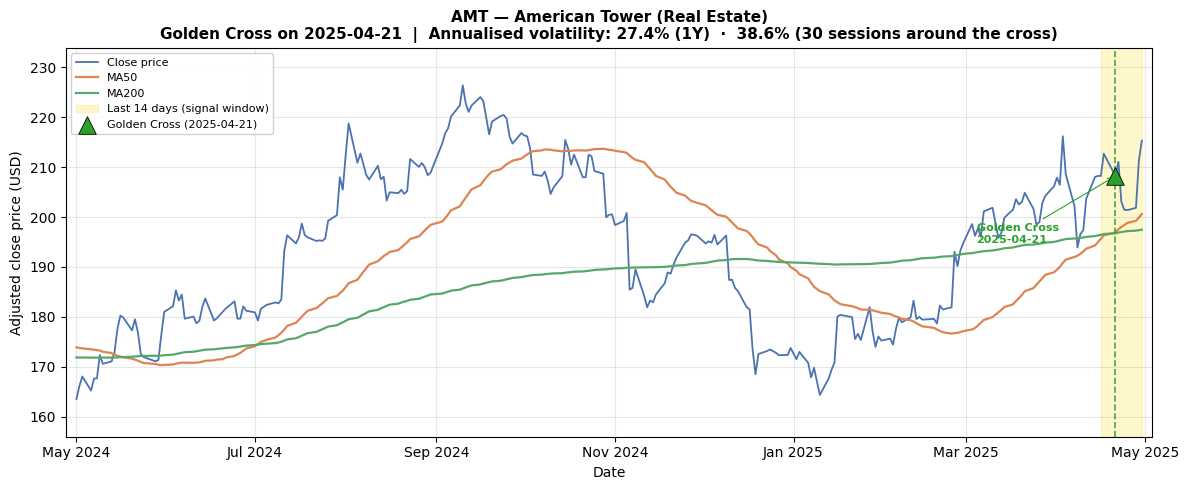

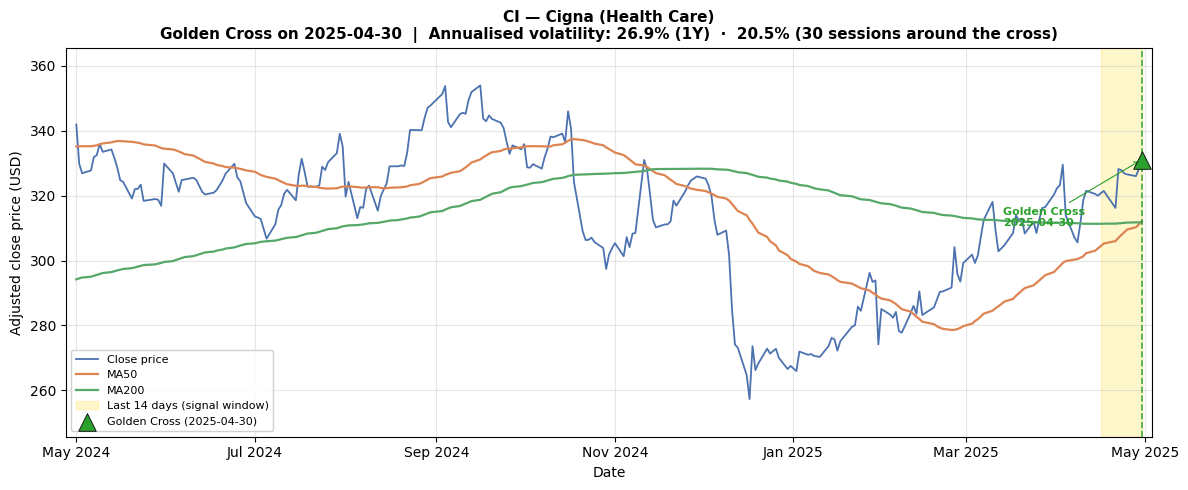

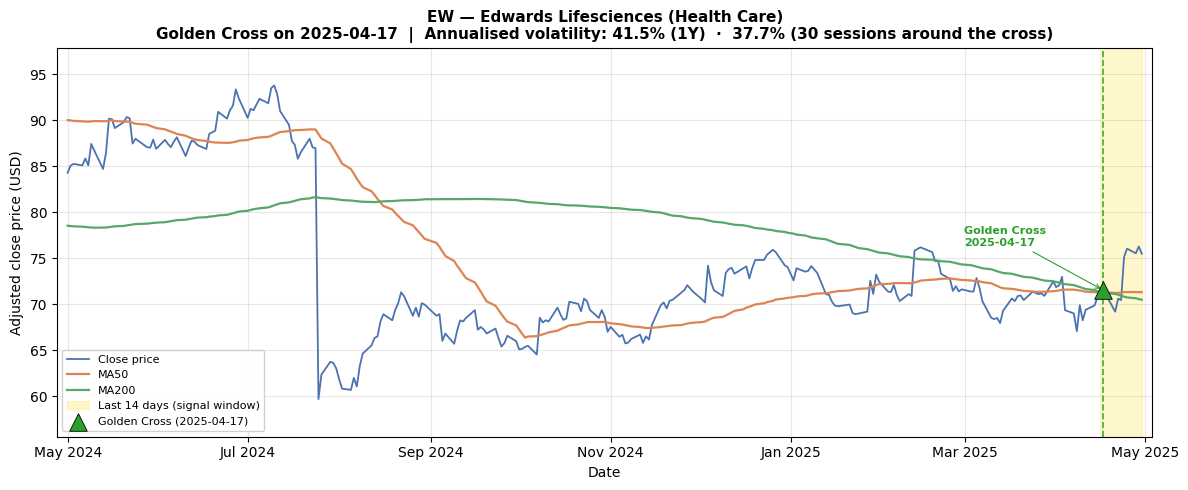

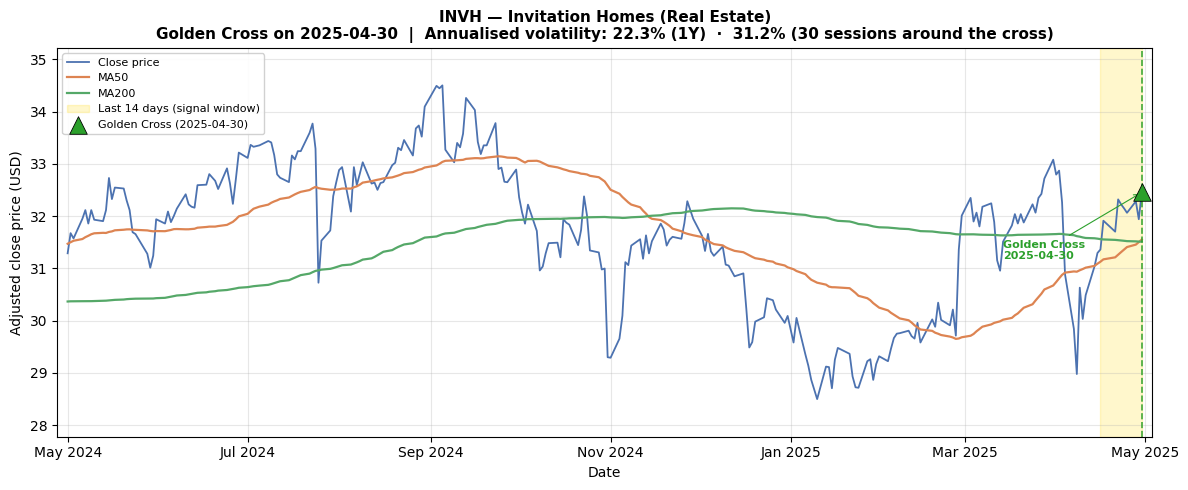

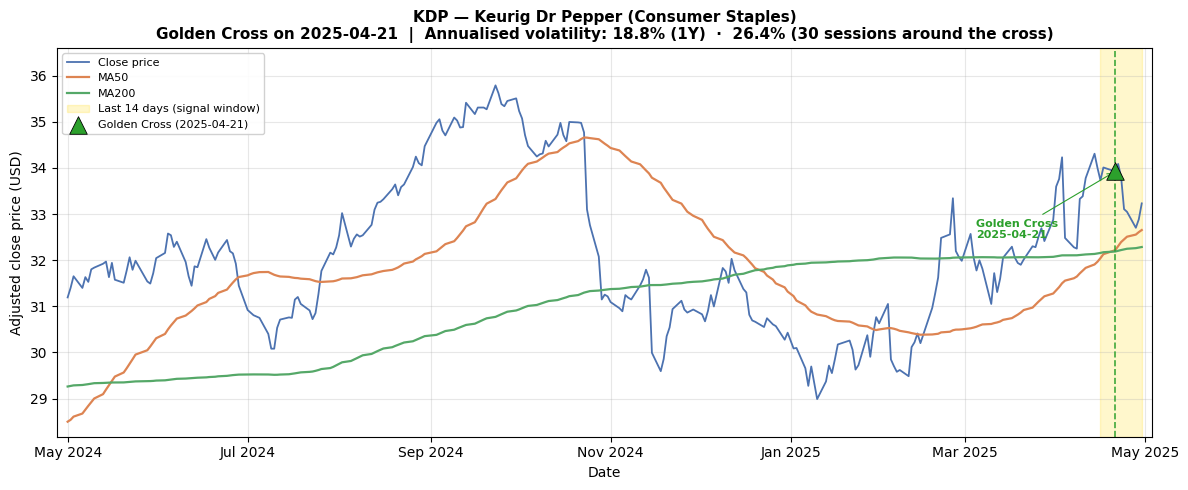

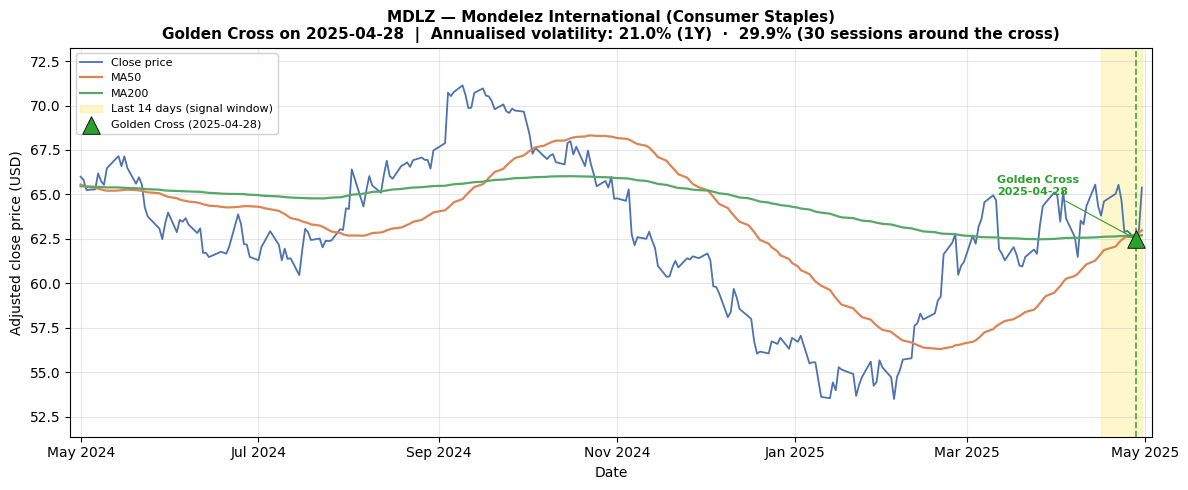

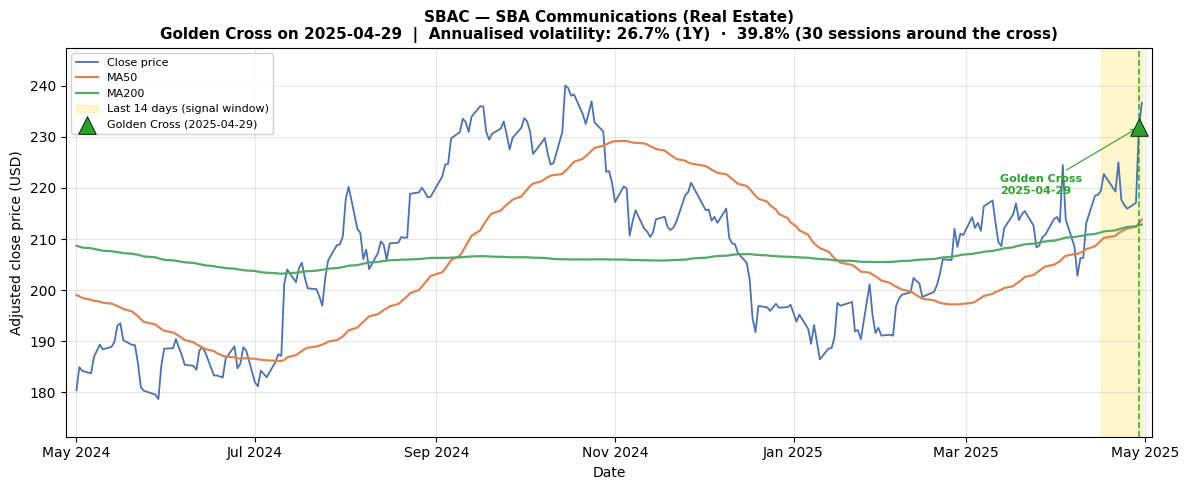

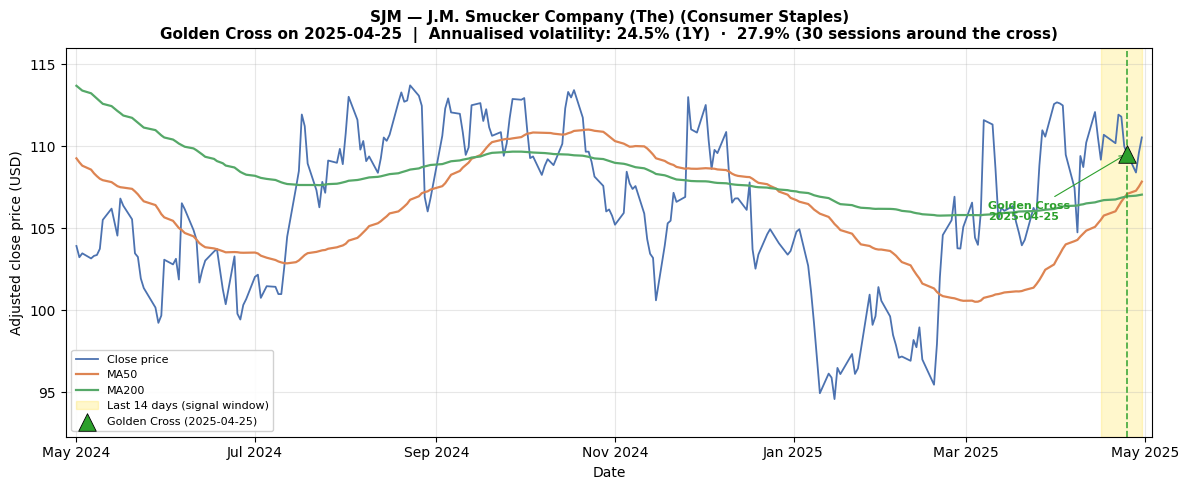

In [28]:
plot_top10(df_golden_cross_14d, 'GOLDEN')

### Plot top 10 stocks that had Death Crosses in the last 14 days

You should have 10 plots (use a for loop) for every stock in the top 10 (in alphabetical order)
For each plot, put the volatility of the stock in the title of the plot

Plotting 10 DEATH cross stocks (alphabetical order): AME, AMP, AMZN, APD, APO, AXP, CCL, CEG, CIEN, CMI



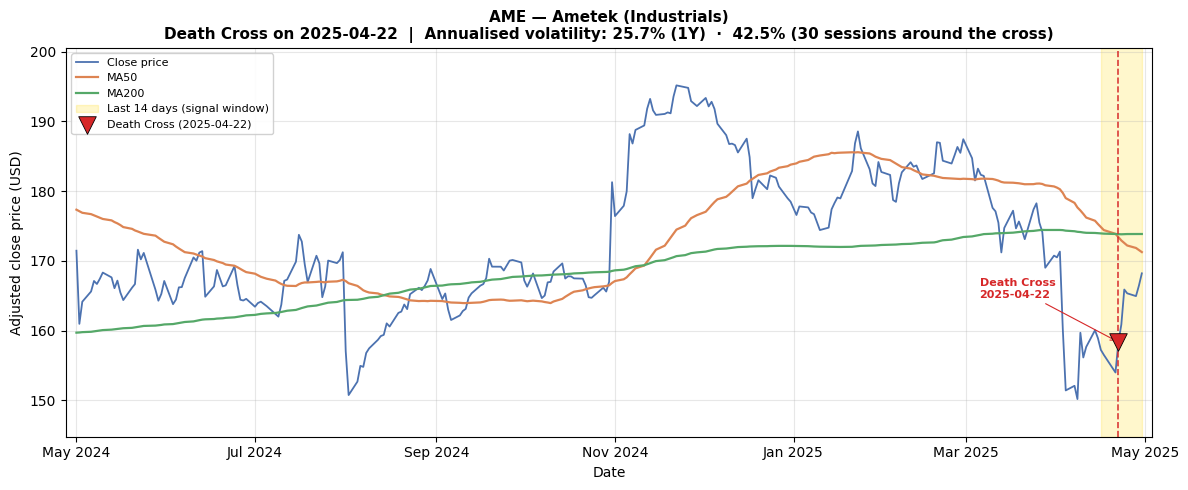

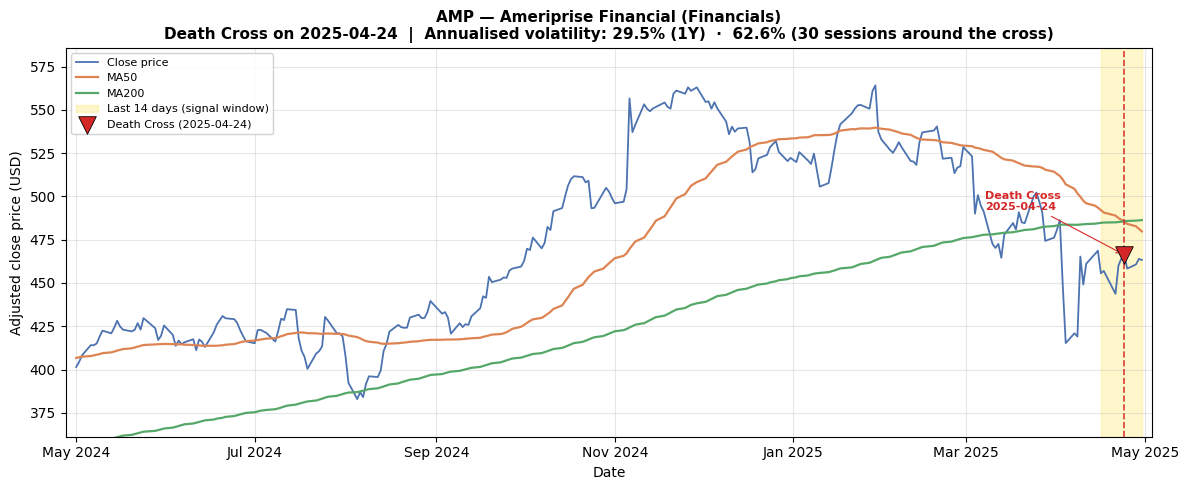

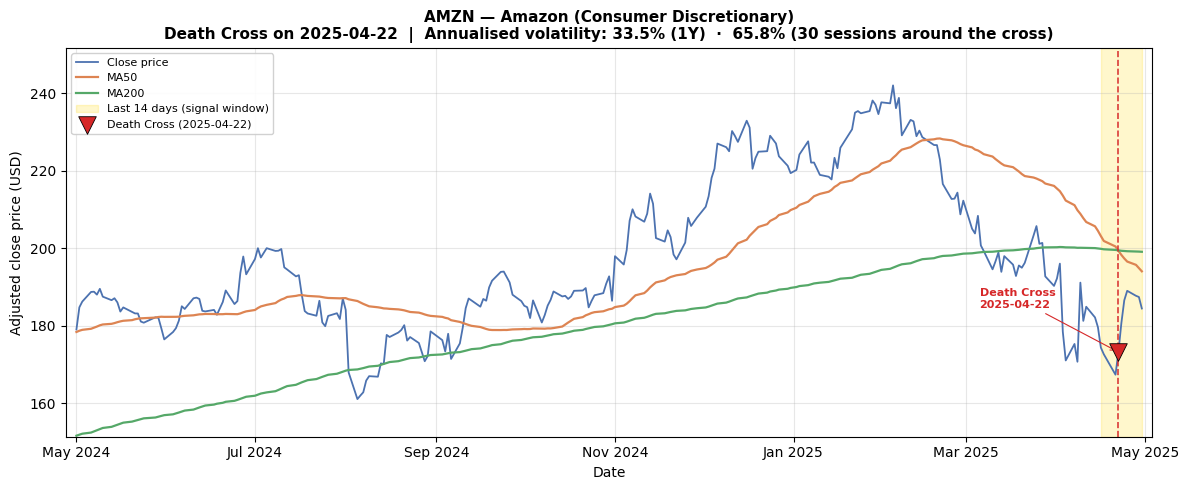

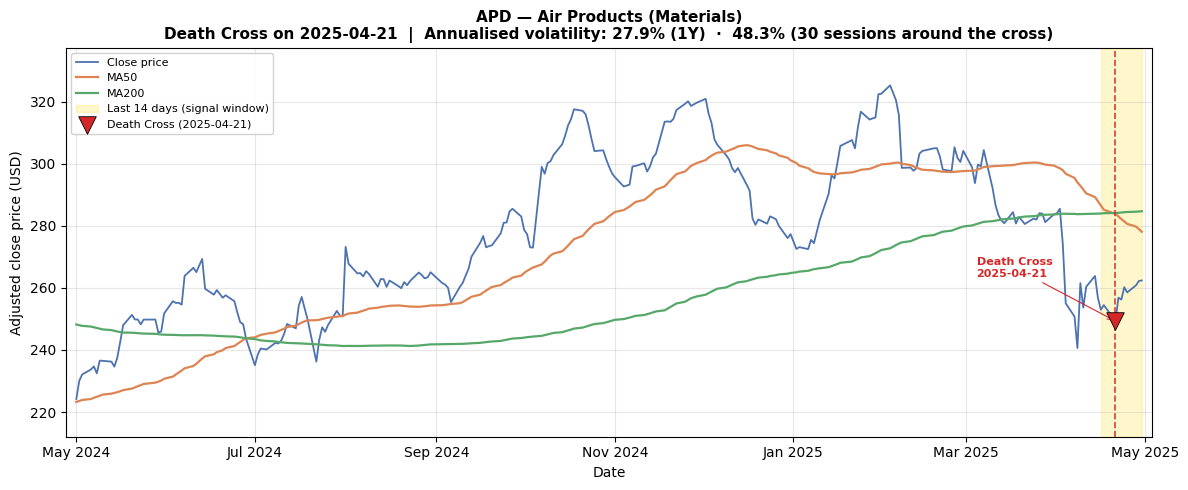

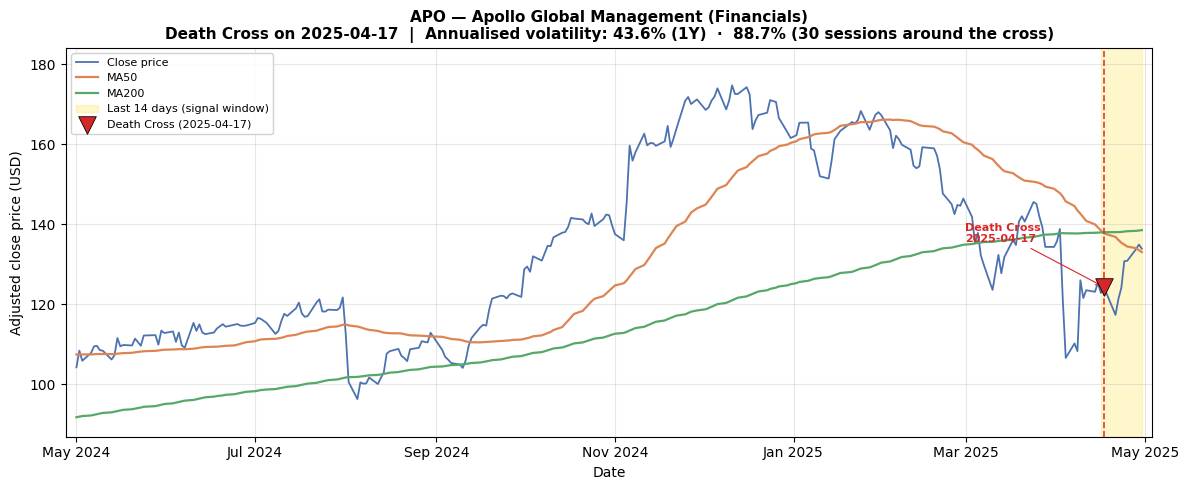

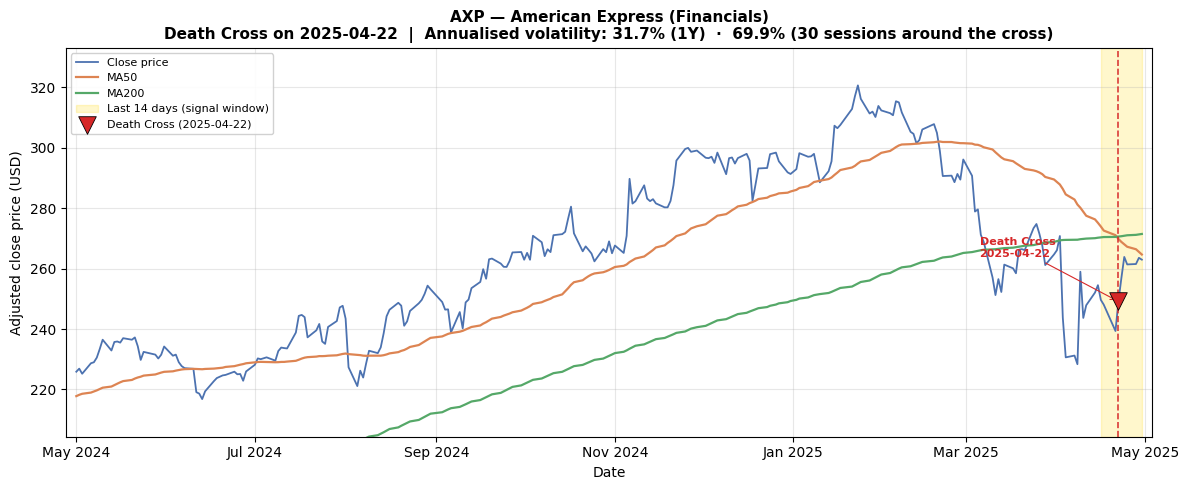

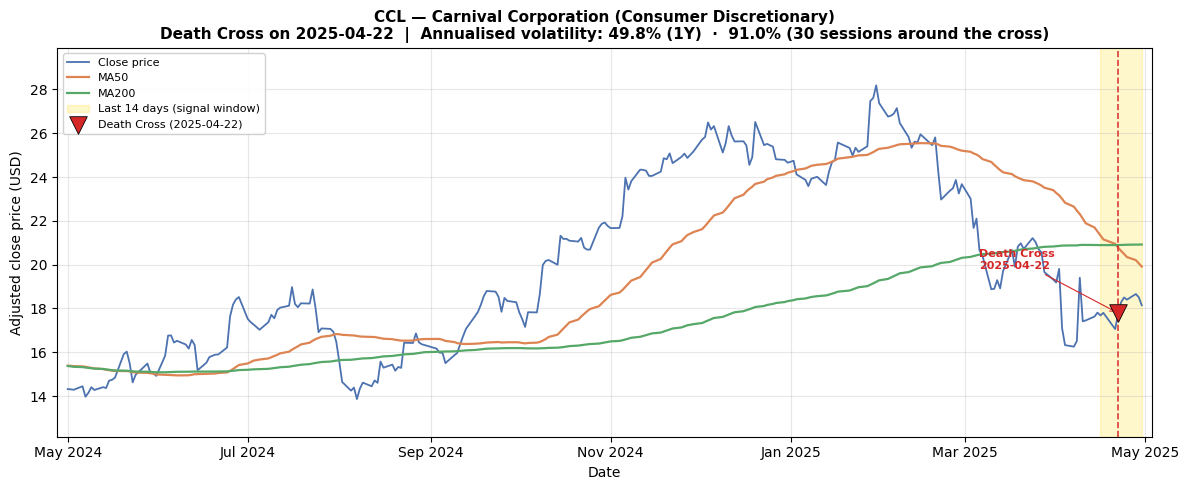

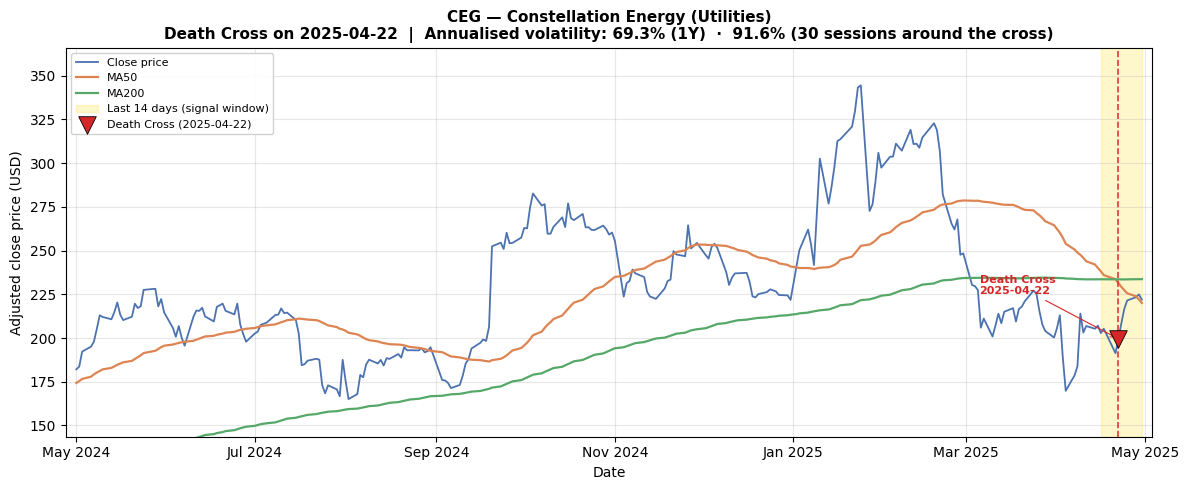

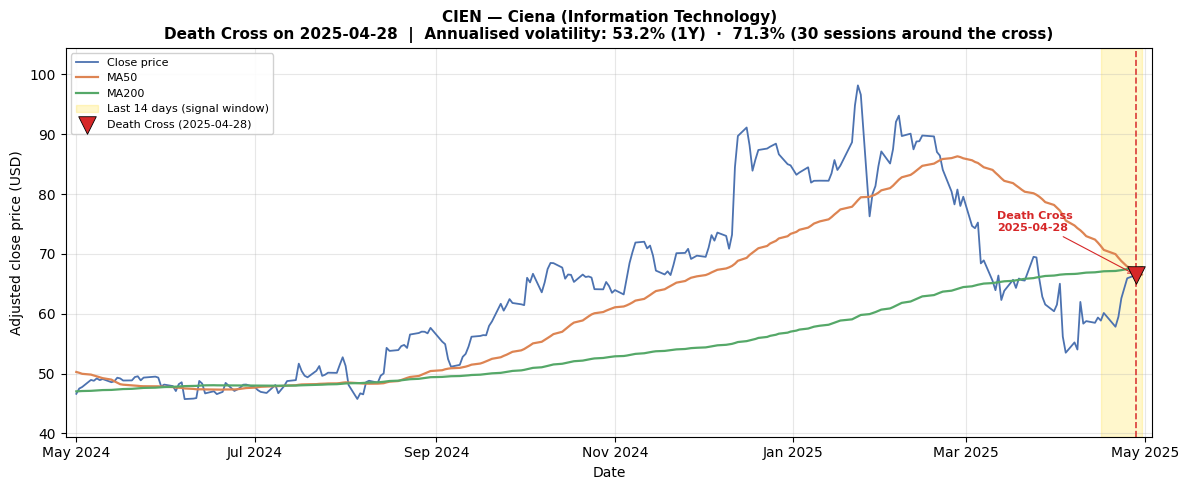

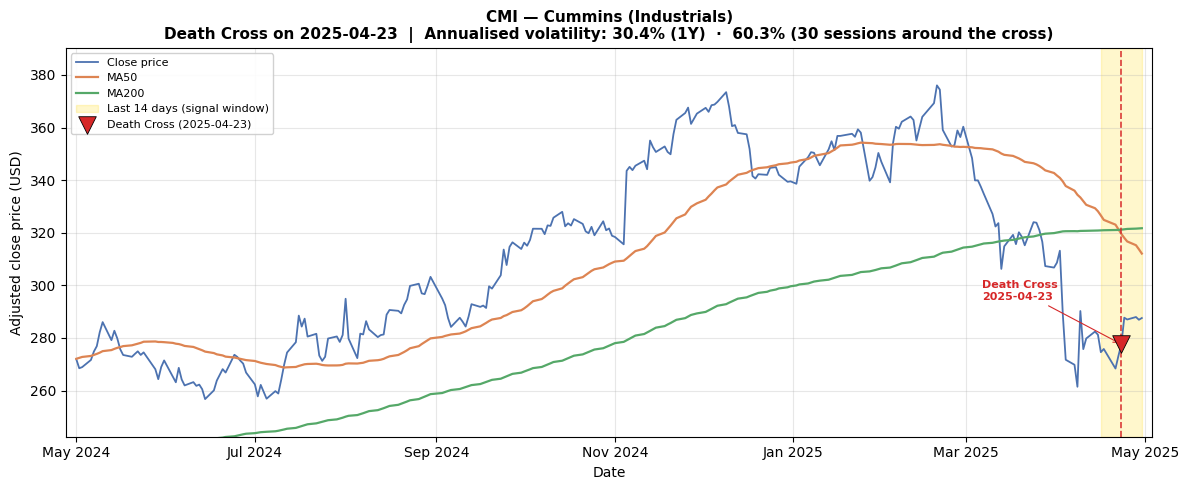

In [29]:
plot_top10(df_death_cross_14d, 'DEATH')

#### Volatility in context

A single number in a title is hard to judge, so the chart below places the volatility of the signalled
stocks against the distribution of the whole index. If the crossing names sit systematically in the
right tail, the "signal" may be little more than noisy stocks whipsawing around their own averages.

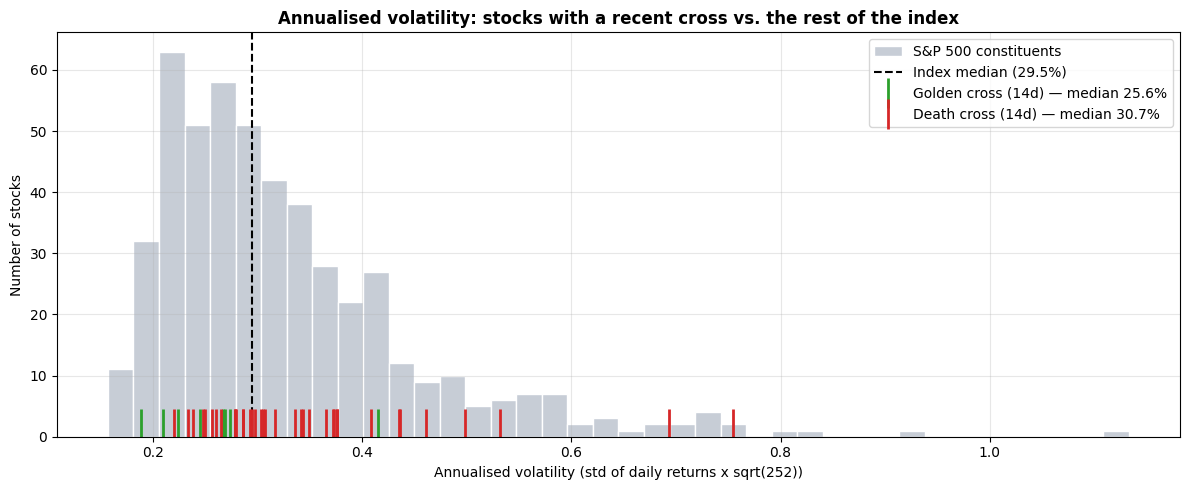

In [30]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(vol_annual.dropna(), bins=40, color='#c7cdd6', edgecolor='white',
        label='S&P 500 constituents')
ax.axvline(vol_annual.median(), color='black', ls='--', lw=1.5,
           label=f"Index median ({vol_annual.median():.1%})")

for df_sig, colour, label in ((df_golden_cross_14d, '#2ca02c', 'Golden cross (14d)'),
                              (df_death_cross_14d, '#d62728', 'Death cross (14d)')):
    if not df_sig.empty:
        ax.plot(df_sig['VOL_ANNUAL_1Y'], np.full(len(df_sig), 2), '|', ms=22, mew=2,
                color=colour, label=f"{label} — median {df_sig['VOL_ANNUAL_1Y'].median():.1%}")

ax.set_title('Annualised volatility: stocks with a recent cross vs. the rest of the index',
             fontweight='bold')
ax.set_xlabel('Annualised volatility (std of daily returns x sqrt(252))')
ax.set_ylabel('Number of stocks')
ax.legend()
plt.tight_layout()
plt.show()

---
## Backtesting the signal (event study)

Answering *"does a Golden Cross actually make money?"* requires more than looking at the last 14 days,
so we run a simple **event study** on every cross detected during the year: for each signal we measure
the forward return over 5, 10, 21 and 63 trading sessions and compare it with the **unconditional**
return of the same stocks over the same horizons (the "do nothing special" benchmark).

Caveats, stated up front: one year of data on a single (bullish) regime is a very small sample, the
forward window is truncated for the most recent signals, and the study ignores transaction costs and
survivorship bias — today's S&P 500 membership list excludes companies that were dropped from the
index during the period.

In [31]:
HORIZONS = [5, 10, 21, 63]


def forward_returns(df_signals, horizons=HORIZONS):
    """Return, for each cross, the forward return over each horizon (in trading sessions)."""
    out = df_signals.copy()
    idx = df_close.index
    for h in horizons:
        rets = []
        for ticker, date in zip(out['TICKER'], out['CROSS_DATE']):
            pos = idx.get_indexer([date])[0]
            if pos == -1 or pos + h >= len(idx):
                rets.append(np.nan)                       # not enough future data yet
                continue
            p0, p1 = df_close[ticker].iloc[pos], df_close[ticker].iloc[pos + h]
            rets.append(p1 / p0 - 1 if pd.notna(p0) and pd.notna(p1) else np.nan)
        out[f'FWD_{h}D'] = rets
    return out


df_events = forward_returns(enrich(df_crosses))
print(f"Events studied: {len(df_events)} "
      f"({(df_events['CROSS_TYPE'] == 'GOLDEN').sum()} golden / "
      f"{(df_events['CROSS_TYPE'] == 'DEATH').sum()} death)")
display(df_events.head())

Events studied: 709 (242 golden / 467 death)


,TICKER,CROSS_TYPE,CROSS_DATE,CLOSE_AT_CROSS,MA50_AT_CROSS,MA200_AT_CROSS,MA_SPREAD_PCT,VOL_ANNUAL_1Y,VOL_30D_AROUND_CROSS,COMPANY,SECTOR,FWD_5D,FWD_10D,FWD_21D,FWD_63D
0,DE,GOLDEN,2024-05-02,384.122620,377.336367,377.002786,0.088483,0.287517,0.254982,Deere & Company,Industrials,0.032933,-0.003864,-0.070310,-0.103102
1,FSLR,GOLDEN,2024-05-02,180.509995,165.119400,164.460950,0.400369,0.586182,0.815707,First Solar,Information Technology,0.072572,0.078167,0.510830,0.180267
2,EVRG,GOLDEN,2024-05-03,49.511620,47.128417,47.034420,0.199847,0.156924,0.172672,Evergy,Utilities,0.024399,0.030579,0.020668,0.094347
3,INTC,DEATH,2024-05-03,30.581005,39.166847,39.293257,-0.321710,0.628388,0.278094,Intel,Information Technology,-0.030057,0.034281,-0.024208,-0.346547
4,MDLZ,DEATH,2024-05-03,65.246552,65.430517,65.445029,-0.022175,0.209580,0.151288,Mondelez International,Consumer Staples,0.018744,0.019173,-0.025755,-0.006250


In [32]:
# Benchmark: unconditional forward returns of the same universe over the same horizons
baseline = {f'FWD_{h}D': (df_close.shift(-h) / df_close - 1).stack().mean() for h in HORIZONS}

summary = []
for cross_type in ['GOLDEN', 'DEATH']:
    sub = df_events[df_events['CROSS_TYPE'] == cross_type]
    for h in HORIZONS:
        col = f'FWD_{h}D'
        series = sub[col].dropna()
        summary.append({
            'CROSS_TYPE': cross_type,
            'HORIZON_DAYS': h,
            'N_EVENTS': len(series),
            'MEAN_RETURN': series.mean(),
            'MEDIAN_RETURN': series.median(),
            'HIT_RATE': (series > 0).mean(),
            'BASELINE_MEAN': baseline[col],
            'EXCESS_VS_BASELINE': series.mean() - baseline[col],
        })

df_backtest = pd.DataFrame(summary)
display(df_backtest.style.format({
    'MEAN_RETURN': '{:+.2%}', 'MEDIAN_RETURN': '{:+.2%}', 'HIT_RATE': '{:.1%}',
    'BASELINE_MEAN': '{:+.2%}', 'EXCESS_VS_BASELINE': '{:+.2%}'}))

,CROSS_TYPE,HORIZON_DAYS,N_EVENTS,MEAN_RETURN,MEDIAN_RETURN,HIT_RATE,BASELINE_MEAN,EXCESS_VS_BASELINE
0,GOLDEN,5,237,+0.39%,+0.17%,52.3%,+0.21%,+0.18%
1,GOLDEN,10,234,+0.52%,+0.41%,53.8%,+0.30%,+0.22%
2,GOLDEN,21,229,+0.51%,+0.21%,51.5%,+0.44%,+0.07%
3,GOLDEN,63,193,+3.04%,+3.01%,55.4%,+3.06%,-0.01%
4,DEATH,5,454,+0.80%,+1.07%,58.6%,+0.21%,+0.59%
5,DEATH,10,423,+0.90%,+1.61%,59.3%,+0.30%,+0.60%
6,DEATH,21,358,+0.84%,+0.87%,53.4%,+0.44%,+0.40%
7,DEATH,63,272,+4.63%,+3.23%,60.3%,+3.06%,+1.57%


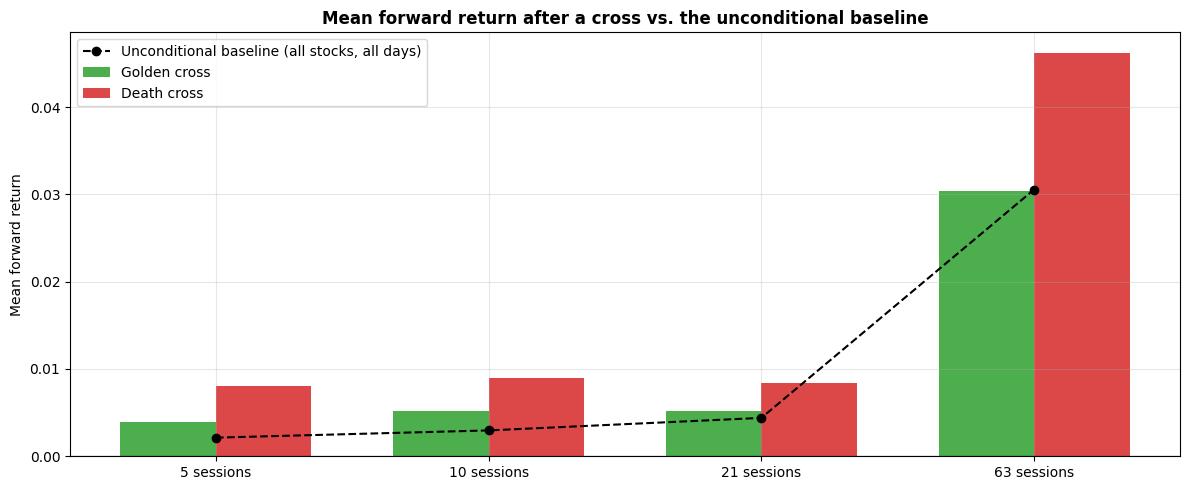

In [33]:
fig, ax = plt.subplots(figsize=(12, 5))
width = 0.35
x = np.arange(len(HORIZONS))

for offset, (cross_type, colour) in zip((-width / 2, width / 2),
                                        (('GOLDEN', '#2ca02c'), ('DEATH', '#d62728'))):
    vals = [df_backtest.query("CROSS_TYPE == @cross_type and HORIZON_DAYS == @h")['MEAN_RETURN'].iloc[0]
            for h in HORIZONS]
    ax.bar(x + offset, vals, width, color=colour, label=f'{cross_type.title()} cross', alpha=0.85)

ax.plot(x, [baseline[f'FWD_{h}D'] for h in HORIZONS], 'k--o', lw=1.5,
        label='Unconditional baseline (all stocks, all days)')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x, [f'{h} sessions' for h in HORIZONS])
ax.set_ylabel('Mean forward return')
ax.set_title('Mean forward return after a cross vs. the unconditional baseline',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [34]:
# Are the differences even distinguishable from noise? A quick two-sample t-test per horizon.
from scipy import stats

for h in HORIZONS:
    g = df_events.query("CROSS_TYPE == 'GOLDEN'")[f'FWD_{h}D'].dropna()
    d = df_events.query("CROSS_TYPE == 'DEATH'")[f'FWD_{h}D'].dropna()
    if len(g) > 2 and len(d) > 2:
        t, p = stats.ttest_ind(g, d, equal_var=False)
        verdict = 'significant at 5%' if p < 0.05 else 'NOT significant at 5%'
        print(f"{h:>3} sessions | golden {g.mean():+.2%} (n={len(g)}) vs death {d.mean():+.2%} "
              f"(n={len(d)}) | t={t:+.2f}, p={p:.3f} -> {verdict}")

  5 sessions | golden +0.39% (n=237) vs death +0.80% (n=454) | t=-1.15, p=0.250 -> NOT significant at 5%
 10 sessions | golden +0.52% (n=234) vs death +0.90% (n=423) | t=-0.77, p=0.442 -> NOT significant at 5%
 21 sessions | golden +0.51% (n=229) vs death +0.84% (n=358) | t=-0.42, p=0.678 -> NOT significant at 5%
 63 sessions | golden +3.04% (n=193) vs death +4.63% (n=272) | t=-1.00, p=0.319 -> NOT significant at 5%


## Question section

### Understanding concepts

#### What is a Golden Cross and what does it typically signal to investors?

A **Golden Cross** occurs when a short-term moving average crosses **above** a long-term moving
average — in the standard formulation used here, when the 50-day simple moving average of the closing
price rises above the 200-day simple moving average. Mechanically it means that the average price
paid over the last ~2.5 months has moved above the average price paid over the last ~10 months: recent
buyers are, on aggregate, paying more than longer-term holders, and the trend of the medium term has
turned up relative to the long term.

To investors it is read as a **confirmation of a bullish regime change**, not as a prediction. Three
things are usually inferred from it:

1. **Trend confirmation.** The down-leg has ended and momentum has flipped; trend-following systems
   move from neutral/short to long.
2. **A moving stop level.** The MA200 becomes the reference line: as long as price holds above it, the
   long thesis is intact, which gives a mechanical, non-emotional exit rule.
3. **A crowding/reflexivity effect.** Because the signal is universally known and published by every
   financial data provider, a Golden Cross on a large name attracts flow from CTAs and momentum funds,
   and generates media coverage that can be partially self-fulfilling in the short term.

Its defining characteristic is that it is a **lagging** indicator: it is built from 50 and 200 days of
history, so by construction it confirms a move that has already happened — typically the price has
already risen 10–25% off the low by the time the cross prints. It buys *confirmation* at the cost of
*timeliness*.

#### What is a Death Cross and how might market participants react to it?

A **Death Cross** is the symmetric event: the MA50 falls **below** the MA200, meaning the recent
average price has dropped under the long-term average and the medium-term trend has turned down. It is
interpreted as confirmation that a correction has become a **downtrend** rather than a dip.

Reactions differ sharply by type of participant, which is important to understand because it explains
why the signal moves prices at all:

* **Systematic trend-followers (CTAs, managed futures)** flip to flat or short mechanically, which is
  the main channel through which the signal becomes partially self-fulfilling.
* **Risk managers and long-only funds** rarely sell purely on a cross, but use it to cut position
  sizes, tighten stops, or hedge with options — the cross acts as a trigger for a *review*, not for a
  liquidation.
* **Retail investors** are the most reactive: "death cross" is a headline-friendly phrase, and its
  appearance in the financial press often coincides with a spike in selling volume.
* **Contrarian and value investors** frequently do the opposite: because the indicator is so lagging,
  a Death Cross often prints *near* a local bottom, after the bulk of the decline is already priced in
  (the March 2020 death crosses printed within days of the low).

The practical caveat is the **whipsaw**: in a choppy, range-bound market the two averages can cross
back and forth repeatedly, generating a Death Cross that is reversed by a Golden Cross a few weeks
later, and each round trip costs spread, commission and taxes.

#### Why might moving averages (MA50, MA200) be used as indicators in technical analysis?

Moving averages are used because they solve a very specific problem: **daily prices are dominated by
noise**, and the human eye (and most statistical rules) cannot separate a trend from that noise
without smoothing. A moving average is the simplest possible low-pass filter — it removes
high-frequency variation and leaves the slow-moving component that trend-following seeks to exploit.

Concretely they are attractive because:

* **They are objective and reproducible.** Unlike "head and shoulders" or trendline patterns, an MA
  crossover is fully mechanical: two analysts computing MA50/MA200 on the same data get identical
  signals. This is what makes them backtestable.
* **They summarise cost basis.** The MA200 is a decent proxy for the average price paid by holders over
  the past year; price above it means the median holder is in profit — which has real behavioural
  consequences for selling pressure.
* **The horizons are meaningful.** ~50 trading days ≈ one quarter (one earnings cycle); ~200 trading
  days ≈ one trading year. The two windows therefore compare "the current quarter's regime" with "the
  annual regime", which maps onto how institutional allocations are actually reviewed.
* **They are self-reinforcing (a Schelling point).** Because so many participants watch the same two
  lines, they become de-facto support/resistance levels. Their popularity is itself a source of their
  (limited) predictive power.
* **They are trivially cheap to compute** for thousands of assets — as this notebook shows, the whole
  index is two `rolling().mean()` calls.

The counterpart of the smoothing is **lag**: an N-day simple moving average lags the underlying series
by roughly N/2 days. MA200 therefore reacts to a turn with roughly a 100-day delay, which is exactly
why crossovers confirm trends rather than anticipate them, and why they perform well in persistent
trends and badly in range-bound markets.

#### Why are the last 14 days used to check for crosses? What are the implications of this choice?

The 14-day filter exists to make the output **actionable**. A crossover detected 8 months ago is
history: the move it announced has already played out, and it tells a trader nothing about what to do
today. Restricting attention to ~14 calendar days (≈10 trading sessions) keeps only signals that are
still "fresh" — recent enough that the entry price is close to today's price, but old enough (a few
sessions) to have survived an immediate reversal. It also keeps the output list short enough to be
reviewed by a human analyst, which matters when screening 500 names.

**Implications and trade-offs:**

* **Calendar days ≠ trading days.** 14 calendar days contain only ~10 sessions, and fewer when a
  holiday falls inside them. The size of the sample therefore varies with where the window lands in the
  calendar; using `BDay(10)` would make the window stable, at the cost of a less intuitive definition.
* **Small, unstable samples.** In a quiet market the window can be empty; after a sharp regime shift it
  can contain dozens of names at once. Any statistic computed on the filtered set (e.g. average
  volatility of the "signal group") is therefore very noisy — this is a screening tool, not a sample
  for inference. This is precisely why the back-test above uses *all* crosses of the year, not the
  14-day subset.
* **No confirmation period.** 14 days is short enough that some of the crosses in the list are
  *unconfirmed*: the averages may cross back within days. A common professional refinement is to
  require the spread between the averages to stay positive for k consecutive sessions, or to exceed a
  minimum percentage (`MA_SPREAD_PCT` in our table is designed for exactly this filter) — at the price
  of entering later.
* **Look-ahead risk if implemented carelessly.** The window is defined relative to the last date of the
  sample; in a live system it must be re-anchored to "today", and the cross must be computed on
  *closed* bars only, otherwise an intraday print can create a signal that disappears at the close.
* **Endpoint sensitivity.** Because the window is anchored to the end of the data, the answer to
  "which stocks crossed?" is not stable through time — re-running this notebook a week later
  legitimately produces a different list. That is a property of the screen, not a bug, but it must be
  disclosed when the results are presented.

#### How does volatility (e.g., measured using percentage change standard deviation) help contextualize the price movement around crosses?

Volatility is the **denominator** that turns a raw signal into a risk-adjusted one. A crossover in a
stock whose annualised volatility is 15% and the same crossover in a stock at 70% are not comparable
events, for three reasons:

1. **It calibrates the reliability of the signal.** Moving averages are estimates of a trend, and their
   sampling error scales with volatility. In a high-volatility name the MA50 and MA200 sit close
   together in units of daily standard deviation, so they cross frequently and largely at random — the
   classic whipsaw. A cross in a 15%-vol utility carries much more information per event than a cross
   in a 70%-vol biotech. Normalising the gap between the averages by volatility
   (`MA_SPREAD_PCT / VOL`) is the natural way to rank signals by conviction, and it is why the two
   volatility columns are attached to every signal in `df_crosses_14d`.
2. **It sizes the position and the stop.** Practitioners do not buy "100 shares"; they buy an amount
   such that a 1-σ adverse move costs a fixed fraction of the book (volatility targeting). The
   annualised volatility in the plot titles is what converts "buy the Golden Cross" into an actual
   trade size, and it sets the distance at which a stop can be placed without being hit by ordinary
   noise.
3. **It describes the state of the market around the event.** Comparing `VOL_30D_AROUND_CROSS` with
   `VOL_ANNUAL_1Y` says whether the cross happened in a calm, orderly trend (local vol ≤ 1-year vol —
   typically a healthier signal) or inside a stress episode (local vol well above the 1-year level),
   where the crossover is more likely to be an artefact of a violent move that will mean-revert. Rising
   volatility around a Golden Cross is a warning that the "trend" is really a high-variance bounce.

The histogram plotted above adds the population view: it shows whether the signalled names are ordinary
members of the index or systematically the most volatile ones — if the latter, part of any measured
"edge" is simply compensation for higher risk rather than genuine predictive power, and any comparison
of returns must be risk-adjusted (Sharpe, or returns per unit of volatility) rather than raw.

**What the data actually shows in this run.** The two volatility columns separate the two groups of
signals almost perfectly:

| | Golden crosses (n = 8) | Death crosses (n = 37) |
|---|---|---|
| Median 1-year annualised volatility | 25.6% | 30.7% |
| Median volatility around the cross | 30.5% | **62.6%** |
| Median ratio local / 1-year | 1.40× | **1.90×** |
| Signals with local volatility *below* the 1-year level | 2 of 8 | **0 of 37** |

The median S&P 500 constituent had an annualised volatility of 29.5% over the year, so the Golden
Cross names (25.6%) were *calmer than the index* while the Death Cross names (30.7%) were slightly
more volatile — and, far more importantly, **every single Death Cross printed inside a volatility
spike**: local volatility was above the stock's own 1-year level in 37 cases out of 37, reaching
90.9% for CCL and 91.6% for CEG against 1-year levels of 49.8% and 69.3%. These crossovers are not
the product of a slow trend change; they are the mechanical consequence of a violent drawdown
dragging the MA50 through the MA200.

That distinction is exactly what the volatility columns are for. A Death Cross at 1.9× normal
volatility is a *stress* signal, and stress episodes are the situations in which mean reversion is
most likely — which is precisely what the event study below finds. Meanwhile CI (local 20.5% vs.
1-year 26.9%) and SJM (27.9% vs. 24.5%) crossed in relatively orderly conditions, which is the
profile a trend-follower should prefer. Without the volatility context, all 45 signals would look
interchangeable on a list of tickers.

### Backtesting and evaluation

#### How would you measure whether Golden Crosses actually lead to profitable trades?

By running a disciplined **event study** first and a **portfolio back-test** second — the two answer
different questions, and the notebook implements the first one above.

**1. Event study (does the signal carry information?)**
For every Golden Cross in a long history, measure the forward return over several horizons (5, 10, 21,
63 sessions — the `FWD_*` columns computed above) and compare it with a benchmark. The benchmark is the
crux: the raw average return after a Golden Cross is positive mostly because *stocks go up on average*.
Valid controls are (a) the unconditional mean return of the same universe over the same horizons —
implemented above as `BASELINE_MEAN`; (b) the contemporaneous return of the S&P 500 index, to strip out
market beta; (c) a matched sample of non-signalling stocks with similar sector and volatility.
Report mean **and** median (returns are skewed), the **hit rate**, and a test of statistical
significance — the Welch t-test in the cell above is the minimum, though returns are non-normal and
overlapping windows make observations dependent, so a bootstrap or block-bootstrap over event dates is
the honest version.

**2. Portfolio back-test (would the rule have made money?)**
Turn the signal into a full trading rule and simulate it end to end: enter at the *next* session's open
after the cross (never at the closing price that generated it — that is look-ahead bias), define an
exit (a Death Cross, a fixed horizon, a trailing stop), size positions by volatility, cap the number of
concurrent positions, and subtract realistic costs (commission + half the bid-ask spread + slippage,
typically 5–15 bps per side for S&P 500 names). Then evaluate: CAGR, volatility, **Sharpe and Sortino**,
maximum drawdown, turnover, hit rate, average win/average loss, and — most importantly — the return
**relative to buy-and-hold on SPY**, since a long-only trend rule in a bull market will look brilliant
in absolute terms while underperforming a passive index.

**3. Validation discipline (is the result real?)**
Split the history into in-sample and out-of-sample periods and check the rule survives both; test
across regimes (2008, 2018, 2020, 2022) rather than a single bull year; correct for **survivorship
bias** by using the *historical* index membership rather than today's constituents; account for
overlapping events; and count every parameter you tried (50/200 vs 20/100 vs 10/50) — testing many
combinations and reporting the best one is data-snooping, and a Deflated Sharpe Ratio or White's
Reality Check is the proper adjustment.

Applied to this notebook, the honest conclusion is bounded by the data: one year, one regime, ~a few
hundred events, forward windows truncated for the most recent signals. That is enough to *illustrate*
the methodology and to reject the strongest claims, not enough to validate a strategy.

#### What are the risks of using only technical indicators like moving averages without incorporating fundamentals?

* **No notion of value — you can buy an expensive falling knife or sell a cheap compounding asset.**
  A moving average knows nothing about earnings, leverage or cash flow. A Golden Cross on a company
  whose margins are collapsing is a momentum artefact; a Death Cross on a solid business trading at 10×
  earnings is often a gift to a value buyer. Price alone cannot distinguish the two.
* **Blindness to the catalyst, and therefore to the risk.** The rule cannot tell whether a downtrend is
  caused by a temporary logistics problem or by a solvency issue, an accounting fraud or a patent
  cliff. In the tail cases (Enron, Wirecard, SVB, Credit Suisse) fundamentals and news gave a warning
  that price smoothing structurally lags by ~100 days.
* **Event risk that no MA can anticipate.** Earnings, guidance cuts, FDA rulings, M&A, index inclusion
  and macro prints move prices by multiples of daily volatility in a single gap. Gaps jump *over* stop
  levels, so a strategy whose risk control is "the MA200 is my stop" is not actually protected.
* **Whipsaw and cost drag in range-bound markets.** Trend rules are profitable in ~30% of the time
  (persistent trends) and bleed in the rest. Without a regime or trend-strength filter (ADX, realised
  vol, distance between averages), the accumulated round-trip costs and taxes can exceed the gross edge.
* **Structural false positives.** Splits, special dividends, corporate actions and thin liquidity all
  produce mechanical crossovers with no economic content — using adjusted closes (as here,
  `auto_adjust=True`) removes most, but not all, of them.
* **Crowding.** Precisely because it is famous and free, the MA50/MA200 crossover is arbitraged by
  faster participants. Any edge that exists is thin, decays as it becomes better known, and is the
  first to be front-run.
* **A false sense of rigour.** Numerical output looks scientific. Backtested on a single bull year,
  almost any long-only rule will show attractive statistics — the danger is confusing *quantified* with
  *validated*.

The reasonable conclusion is not that technical analysis is useless, but that MA crossovers are a
**timing and risk-management layer**, most defensible when combined with a fundamental or
sentiment-based view of *what* to trade, while the technicals decide *when* and *how much*.

#### How would you improve this strategy to reduce false signals (e.g., a Golden Cross that doesn’t lead to a price increase)?

**A. Make the signal itself harder to trigger**

1. **Minimum separation (noise band).** Require `MA50 > MA200 × (1 + δ)` with δ ≈ 0.5–1%, instead of a
   bare crossing. The `MA_SPREAD_PCT` column already computed makes this a one-line filter and removes
   the marginal crossings that reverse immediately.
2. **Volatility-normalised threshold.** Better than a fixed δ: require the spread to exceed
   *k × daily volatility*, so the bar adapts to each stock (a 1% spread means something very different
   for a utility and for a biotech).
3. **Confirmation delay.** Require the condition to hold for 3–5 consecutive sessions, or that price
   close above the MA200 as well. This mechanically eliminates one-day whipsaws at the cost of a later
   entry.
4. **Exponential or double-smoothed averages.** EMAs react faster than SMAs for the same window;
   pairing them with a slope condition (`MA200` must itself be flat-to-rising for a Golden Cross to
   count) rejects crosses that occur inside an established downtrend.

**B. Add confirmation from independent information**

5. **Volume confirmation.** A cross accompanied by above-average volume (or a rising OBV) is far more
   likely to reflect real institutional repositioning than one on thin volume.
6. **Market and sector regime filter.** Only take long signals when the index itself is above its own
   MA200, and prefer stocks whose sector is outperforming — a single-name Golden Cross in a bear
   market fails far more often.
7. **Cross-indicator agreement.** Require RSI or MACD not to be in extreme/divergent territory, and use
   relative strength versus the index rather than absolute price for the crossover.
8. **Fundamental and news screens.** Exclude names with deteriorating earnings revisions, or with
   pending binary events; and — the bridge to Section A — use news embeddings/sentiment to check that
   the move is not driven by a one-off headline. A Golden Cross with improving fundamentals and
   positive news flow is a materially different trade from a technically identical one on a company
   under investigation.

**C. Manage the trade, not just the entry**

9. **Volatility-based sizing and stops** (ATR multiples), so no single false positive can dominate the
   P&L; and diversification limits per sector.
10. **Predefined exit rules** — a Death Cross, a time stop (if the trade has not worked in N sessions,
    the signal has failed), or a trailing stop — since most of the damage from false positives comes
    from holding them, not from entering them.

**D. Validate honestly.** Every filter added above is a parameter, and every parameter is an
opportunity to overfit. Each one should be justified *ex ante*, tested out-of-sample and across
regimes, and evaluated on the basis of whether it improves the Sharpe ratio net of costs — not merely
whether it removes signals that failed in hindsight.

**Why filter A.1 matters most in this particular run.** The `MA_SPREAD_PCT` column shows that the
eight Golden Crosses detected here are **marginal to the point of being fragile**: the gap between
MA50 and MA200 at the crossing date ranges from **+0.07% (EW) to +0.18% (SBAC)**, with a median of
just **+0.10%**. In other words, the two averages are effectively touching — a fraction of a single
day's move in stocks whose daily volatility is around 1.5–2%. Any of these signals could be reversed
by one ordinary session, which is the textbook definition of a whipsaw.

Applying a minimum-separation filter of δ = 0.5% would have eliminated **all eight** of them. Applying
the volatility-normalised version (requiring the spread to exceed, say, 0.25 × daily volatility) would
also have removed nearly all. That is not an argument against the filter — it is the filter working:
the honest reading of this window is that the index produced **no confirmed bullish crossover at all**,
and a screen that returns eight unconfirmed ones is inviting eight false positives.

The Death Crosses are a degree firmer (median absolute spread 0.18%, up to 0.87% for CEG), but the
same conclusion applies. Note also how the confirmation-delay filter (A.3) interacts with the 14-day
window: several of these crosses are only two or three sessions old at the end of the sample, so
there has not yet been time to know whether they hold. Reporting the spread alongside the signal — as
this notebook does — is what makes that judgement possible instead of implicit.

### AI Integration

#### Could sentiment from news (future project part) help validate or invalidate these technical signals?

Yes, and mainly by supplying the one thing a moving average structurally cannot: the **cause** of the
move and its **timeliness**. Price smoothing lags by design; news arrives first. Combining them is
therefore complementary rather than redundant.

**How it validates or invalidates a signal:**

* **Corroboration.** A Golden Cross accompanied by a cluster of positive, *fundamental* news — earnings
  beats, guidance raises, contract wins, analyst upgrades — suggests the trend has an economic driver
  and is more likely to persist. That is a "confirmed" signal.
* **Contradiction.** A Golden Cross while the news flow is negative or dominated by speculation
  (short squeeze, meme-driven flows, takeover rumours that later evaporate) is a red flag: the trend
  lacks fundamental support and is more likely to reverse. Symmetrically, a Death Cross with intact
  fundamentals and merely macro-driven weakness may be a buying opportunity for a longer-horizon
  investor rather than an exit.
* **Event classification.** The clustering built in Section A is directly useful here: knowing that a
  stock's recent news falls in the "regulatory/legal" cluster rather than the "product/earnings"
  cluster changes the interpretation of an identical technical picture. Sentiment gives direction;
  the cluster gives the *type* of risk.
* **Explaining the volatility.** A spike in `VOL_30D_AROUND_CROSS` with no news is probably flow or
  liquidity; the same spike with dense negative coverage is information being priced in — a different
  trade in each case.

**How I would actually implement it:** aggregate a per-ticker sentiment score over a window ending at
the cross date (a finance-tuned model such as FinBERT rather than a generic one, because "beat
expectations" or "outperform" are domain terms that general models misread), normalise it against the
stock's own history and its sector, and use it as a *filter* (take only Golden Crosses with
non-negative sentiment) or as a *ranking* variable when the screen returns more names than can be
traded. The proper test is whether the combined rule improves risk-adjusted returns out of sample
relative to the technical rule alone.

**Serious caveats:** news is noisy, largely already priced within minutes, and full of look-ahead
traps — the publication timestamp must be the one available in real time, not a revised one, and any
back-test must use point-in-time data. Sentiment scores are also often just a proxy for recent returns,
in which case they add nothing to a momentum signal. And most headlines about a stock *follow* the
price move ("Shares of X surge on…"), which creates a circularity that must be controlled for
explicitly.

### Critical thinking

#### From a trading perspective, is this strategy actionable on its own?

**As implemented here: no — it is a screening tool, not a trading strategy.** What the notebook
produces is a *watchlist*: "these names changed technical regime in the last two weeks." A tradeable
strategy needs several components this analysis deliberately does not have.

What is missing:

* **No exit rule, no position sizing, no risk budget.** Entry is only one of the four decisions a
  strategy must make (what, when, how much, when to get out); three are undefined here.
* **No costs, no capacity, no execution assumptions.** Commissions, spread and slippage are unmodelled,
  and entry at the signal close is not achievable in practice.
* **No statistical validation.** One year, one regime, overlapping events, survivorship-biased
  universe. The back-test above is an illustration of the *method*, not evidence of an edge; the
  t-tests are exactly there to show how weak the evidence is at this sample size.
* **No regime or fundamental context.** The rule is known to lose money in range-bound markets, and it
  has no mechanism to detect that it is in one.

What it *is* genuinely good for:

* **Systematic attention allocation.** Reducing 500 names to a handful of technically interesting ones
  is real value for a human analyst with limited time.
* **Risk management and discipline.** "Reduce exposure below the MA200" is a defensible, unemotional
  rule that has historically limited participation in deep drawdowns — its value is in avoiding the
  worst of bear markets, not in generating alpha.
* **A component in a multi-factor process**, where technicals govern timing and sizing while
  fundamentals or sentiment decide the underlying selection.

So: actionable as an input to a process, not as a standalone rule for capital allocation.

#### Based on the volatility observed post-Golden Cross, do these crosses consistently predict upward movement?

**No — and this run produces an unusually clean demonstration of it.** The event study covers all
**709 crossovers** detected during 2024-05 → 2025-05 (242 Golden, 467 Death). The results:

| Horizon | Golden: mean return | Golden: hit rate | Golden: excess vs. baseline | Death: mean return | Death: hit rate | Death: excess vs. baseline |
|---|---|---|---|---|---|---|
| 5 sessions | +0.39% | 52.3% | +0.18% | +0.80% | 58.6% | +0.59% |
| 10 sessions | +0.52% | 53.8% | +0.22% | +0.90% | 59.3% | +0.60% |
| 21 sessions | +0.51% | 51.5% | +0.07% | +0.84% | 53.4% | +0.40% |
| 63 sessions | +3.04% | 55.4% | **−0.01%** | +4.63% | 60.3% | +1.57% |

Three findings, in order of importance:

1. **The Golden Cross added essentially nothing.** Its excess return over the unconditional baseline
   decays from +0.18% at one week to **−0.01% at three months** — that is, after a quarter, buying a
   Golden Cross performed *identically* to buying a random S&P 500 stock on a random day (+3.04% vs.
   a +3.06% baseline). The hit rate never exceeds 55%, i.e. barely distinguishable from a coin flip.
2. **The Death Cross was followed by *higher* returns than the Golden Cross at every single horizon**
   (+4.63% vs. +3.04% at 63 sessions, with a 60.3% hit rate). Read literally, the bearish signal was
   the better long entry — the opposite of what the textbook interpretation predicts. The explanation
   is in the volatility analysis above: these Death Crosses printed inside a stress episode at 1.9×
   normal volatility, and what followed was a rebound. The signal was not detecting a downtrend; it
   was *lagging* a sharp drawdown that then mean-reverted.
3. **None of this is statistically significant.** The Welch t-tests comparing the two groups return
   p-values of **0.250, 0.442, 0.678 and 0.319** across the four horizons — not one is close to the
   5% threshold. So the honest conclusion is not "Death Crosses are bullish"; it is that **this
   sample cannot distinguish either signal from ordinary market noise.**

The methodological caveats reinforce that reading rather than softening it: a single year, a single
regime dominated by the April 2025 sell-off and rebound, overlapping event windows that violate
independence, forward returns truncated for the most recent signals, and a universe based on today's
index membership. The asymmetry of the sample is itself informative — 467 Death Crosses against 242
Golden Crosses means the year was structurally unfavourable to the bullish signal, and any conclusion
drawn from it would not transfer to a trending bull market.

What *would* be needed to answer the question properly: several decades spanning multiple regimes,
returns adjusted for market beta rather than raw, and a correction for the number of parameter
combinations tested. Until then, the defensible statement is that a Golden Cross, on its own, is not
evidence that a stock will rise.

#### If you had to present this analysis to a portfolio manager, what conclusions would you emphasize? What caveats would you include?

**Conclusions (2 bullet points):**

* **The screen works as market intelligence, and right now it is telling a single coherent story: a
  defensive rotation.** In the 14 days to 2025-04-30 the index produced **8 Golden Crosses against 37
  Death Crosses**. Every bullish signal sits in Consumer Staples, Real Estate or Health Care; the
  bearish ones concentrate in Information Technology (9), Financials (7) and Industrials (5), and 6 of
  the 10 largest cluster within three sessions of each other. That is not 45 independent company
  stories — it is one macro event, and the sector cross-tab identifies it in a single table across
  499 stocks. This is the deliverable: a reproducible daily pipeline that converts the whole index
  into one readable signal about market posture.
* **As a return-generating rule, the signal did not survive its own back-test.** Across the 709
  crossovers of the year, the Golden Cross beat the unconditional baseline by +0.18% at one week and
  by **−0.01% at three months** — no edge at any horizon that matters, with hit rates of 51–55%. The
  Death Cross was actually followed by *higher* returns (+4.63% vs. +3.04% at 63 sessions), and no
  difference reached statistical significance (p = 0.25–0.68). The recommendation is therefore to use
  the crosses for **exposure management and attention allocation**, combined with fundamental or
  news-based selection, and not as a standalone entry rule.

**Caveats (3 bullet points):**

* **The signals in this window are technically fragile.** The eight Golden Crosses have a median
  MA50/MA200 spread of just **+0.10%** (range +0.07% to +0.18%) — the averages are effectively
  touching, and a single ordinary session could reverse any of them. A 0.5% minimum-separation filter
  would eliminate all eight. Presented without that number, the list looks like eight opportunities;
  with it, it looks like eight unconfirmed crossings.
* **Sample and regime limits make the back-test indicative only.** One year, one regime dominated by
  the April 2025 sell-off and rebound; 467 Death Crosses vs. 242 Golden Crosses is itself evidence
  that the period was structurally hostile to the bullish signal. Add overlapping event windows,
  forward returns truncated for the most recent signals, survivorship bias from using today's index
  membership (3 tickers were already delisted), and the absence of transaction costs — a gross edge
  of a few basis points would not survive spread and commission anyway.
* **The Death Crosses are stress artefacts, not trend changes, and the volatility data proves it.**
  All 37 printed with local volatility above the stock's own 1-year level (median 1.9×, up to 91.6%
  for CEG), meaning the crossover was the mechanical consequence of a violent drawdown rather than a
  slow deterioration. Acting on them as trend signals at the end of April would have meant selling
  into the low — which is exactly what the subsequent +4.63% average return over 63 sessions
  indicates. The indicator lags by construction (~100 days for the MA200); in a fast drawdown, that
  lag is the whole story.